# Modèle pour la prédiction du débit d'entrée pour la station C

## Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb  
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

/Users/nbieszczad/M2DS/Capstone VINCI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Données 

ATTENTION AU CHANGEMENT D'HEURE ET METTRE LES DONNÉES EN UTC + AJOUTER DONNÉES 2025-2026

In [2]:
# Capteurs
df_sensors = pd.read_csv('/Users/nbieszczad/M2DS/Capstone VINCI/Capstone/Dataset/bronze/sensors_C_20210101_20250101.csv')
df_sensors['ts'] = pd.to_datetime(df_sensors['ts'])

# Débit d'entrée 
df_debit = df_sensors[df_sensors['sensor'] == 'entry_debit'].copy()
df_debit = df_debit.set_index('ts')[['value']].resample('1h').mean() # Le débit est agrégé à l'échelle horaire car les données météo sont à cett échelle.
df_debit.columns = ['debit']

# Météo : dans un premier temps, on va essayer en faisant la moyenne des 14 villes
weather_files = [
    'Aiglemont', 'Chalandry-Elaire', 'Damouzy', 'Dom-le-Mesnil',
    'Flize', 'La-Francheville', 'La-Grandville', 'Les-Ayvelles',
    'Montcy-Notre-Dame', 'Prix-les-Mezieres', 'Saint-Laurent',
    'Ville-sur-Lumes', 'Villers-Semeuse', 'Warcq'
]

weather_frames = []
for city in weather_files:
    try:
        df = pd.read_csv(f'/Users/nbieszczad/M2DS/Capstone VINCI/Capstone/Dataset/bronze/weather_C/{city}_hourly.csv')
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')[['temperature_2m', 'rain', 'wind_speed_10m']].resample('1h').mean()
        weather_frames.append(df)
    except:
        pass

df_weather = pd.concat(weather_frames).groupby(level=0).mean()
if df_weather.index.tz: df_weather.index = df_weather.index.tz_localize(None)

# Fusion
df = pd.merge(df_debit, df_weather, left_index=True, right_index=True, how='inner')


### Features 

In [4]:
# Pluie décalée (LAG 5h) 
df['rain_lag_5'] = df['rain'].shift(5)

# Features temporelles
df['hour'] = df.index.hour
df['month'] = df.index.month

# Encodage cyclique (pour capturer la continuité 23h → 0h). Sans ca, le modele ne pourra pas faire de lien entre 23h et 00H par exemple. 
# Ca va aussi faire que le modele va potentiellement mettre plus de poids sur 23h que 00h car 23>0
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
# Essayer de modéliser la courbe de la tendance de la distribution du débit, et d'avoir un parametre à trouver pour le modèle. 

# Lags du débit (inertie hydraulique)
df['debit_lag_1h'] = df['debit'].shift(1)
df['debit_lag_6h'] = df['debit'].shift(6)                     #Faire la prédiction à 3, 12 et 24h
df['debit_lag_24h'] = df['debit'].shift(24)

# Rolling Statistics (fenêtres glissantes) 
df['debit_roll_mean_24h'] = df['debit'].rolling(window=24, min_periods=1).mean()
df['rain_roll_sum_12h'] = df['rain'].rolling(window=12, min_periods=1).sum()
df['debit_roll_mean_6h'] = df['debit'].rolling(window=6, min_periods=1).mean()
df['rain_roll_sum_6h'] = df['rain'].rolling(window=6, min_periods=1).sum()

# Interactions métier (2eme temps): faire de maniere de plus automatique, polynomial features
# Vaut mieux etre sur avant de mettre ce genre de croisements 
df['temp_x_rain'] = df['temperature_2m'] * df['rain_lag_5']  # Pluie chaude vs froide
df['wind_x_rain'] = df['wind_speed_10m'] * df['rain_lag_5']  # Tempêtes

# Features binaires
#df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)

# Features pour gérer les pics
df['rain_roll_max_3h'] = df['rain'].rolling(window=3, min_periods=1).max()
df['rain_roll_max_6h'] = df['rain'].rolling(window=6, min_periods=1).max()

df['debit_roll_max_6h'] = df['debit'].rolling(window=6, min_periods=1).max()
df['debit_roll_min_6h'] = df['debit'].rolling(window=6, min_periods=1).min()

# Suppression des NaN (dus aux lags)
df_clean = df.dropna()

print(f"Dataset final : {len(df_clean):,} heures")
print(f"Période : {df_clean.index.min()} → {df_clean.index.max()}")
print(f"Features créées : {df_clean.shape[1] - 1} (hors cible)")


Dataset final : 33,368 heures
Période : 2021-01-02 00:00:00 → 2024-12-31 23:00:00
Features créées : 23 (hors cible)


# Prédiction à 3h

## Création des données pour la prédiction à 3h

In [5]:
df_clean['debit_target_3h'] = df_clean['debit'].shift(-3)
df_3h = df_clean.dropna(subset=['debit_target_3h'])

### Split chronologique Train / Validation / Test

In [6]:
feature_cols_3h = [
    'temperature_2m', 'wind_speed_10m', 'rain_lag_5',
    'sin_hour', 'cos_hour', 'sin_month', 'cos_month',
    'debit_lag_6h', 'rain_roll_sum_12h', 'debit_roll_mean_6h',
    'rain_roll_sum_6h', 'rain_roll_max_6h', 'rain_roll_max_3h',
    'debit_roll_max_6h', 'debit_roll_min_6h', 'debit'
]

X = df_3h[feature_cols_3h]
y = df_3h['debit_target_3h']

# Split chronologique 60% / 20% / 20%
n = len(X)
n_train = int(n * 0.60)
n_val   = int(n * 0.20)

X_train = X.iloc[:n_train]
y_train = y.iloc[:n_train]

X_val   = X.iloc[n_train:n_train + n_val]
y_val   = y.iloc[n_train:n_train + n_val]

X_test  = X.iloc[n_train + n_val:]
y_test  = y.iloc[n_train + n_val:]

print(f"Train      : {X_train.index.min().date()} → {X_train.index.max().date()}  ({len(X_train):,} obs)")
print(f"Validation : {X_val.index.min().date()} → {X_val.index.max().date()}  ({len(X_val):,} obs)")
print(f"Test       : {X_test.index.min().date()} → {X_test.index.max().date()}  ({len(X_test):,} obs)")

# Train
model = xgb.XGBRegressor(
    max_depth=3, n_estimators=300, learning_rate=0.05,
    reg_alpha=1.0, reg_lambda=5.0,
    random_state=42
)
model.fit(X_train, y_train)

# Validation
y_pred_val   = model.predict(X_val)
y_pred_train = model.predict(X_train)

def print_metrics(label, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label:12s} → RMSE={rmse:.2f} | MAE={mae:.2f} | R²={r2:.3f}")


print_metrics("Train",      y_train, y_pred_train)
print_metrics("Validation", y_val,   y_pred_val)

gap_r2   = r2_score(y_train, y_pred_train) - r2_score(y_val, y_pred_val)
gap_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val)) - np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"Gap R²   (train-val) : {gap_r2:.3f}")
print(f"Gap RMSE (val-train) : {gap_rmse:.2f}")


Train      : 2021-01-02 → 2023-06-23  (20,019 obs)
Validation : 2023-06-23 → 2024-03-27  (6,673 obs)
Test       : 2024-03-27 → 2024-12-31  (6,673 obs)
Train        → RMSE=141.20 | MAE=83.01 | R²=0.850
Validation   → RMSE=169.82 | MAE=104.85 | R²=0.860
Gap R²   (train-val) : -0.010
Gap RMSE (val-train) : 28.62
Train        → RMSE=141.20 | MAE=83.01 | R²=0.850
Validation   → RMSE=169.82 | MAE=104.85 | R²=0.860
Gap R²   (train-val) : -0.010
Gap RMSE (val-train) : 28.62


Visualisation du débit prédit vs réel sur la **validation** (le test reste caché jusqu'à la fin).

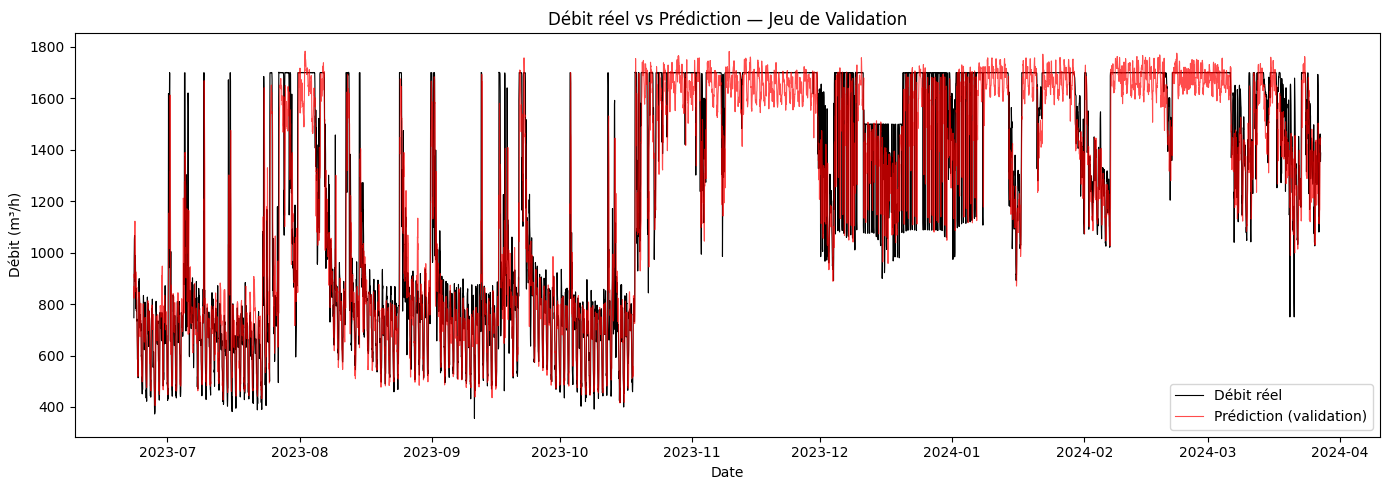

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(y_val.index, y_val, label='Débit réel', color='black', linewidth=0.8)
plt.plot(y_val.index, y_pred_val, label='Prédiction (validation)', color='red', alpha=0.7, linewidth=0.8)
plt.title('Débit réel vs Prédiction — Jeu de Validation')
plt.xlabel('Date')
plt.ylabel('Débit (m³/h)')
plt.legend()
plt.tight_layout()
plt.show()


## Évaluation finale sur le jeu de Test

Train        → RMSE=141.20 | MAE=83.01 | R²=0.850
Validation   → RMSE=169.82 | MAE=104.85 | R²=0.860
TEST         → RMSE=166.79 | MAE=108.18 | R²=0.804


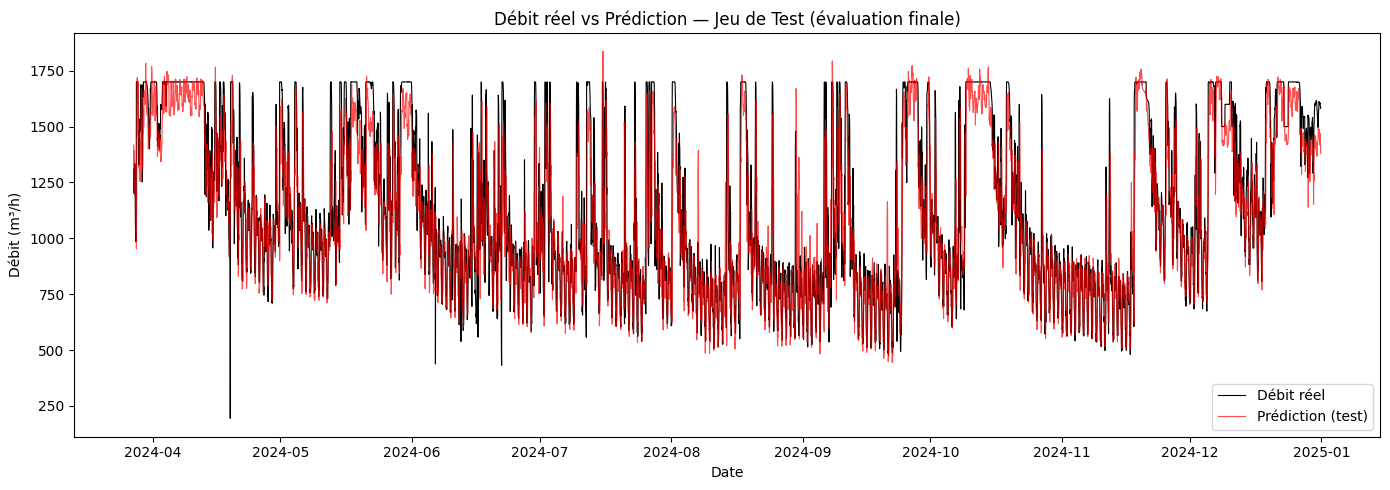

In [12]:
# Évaluation finale sur test
y_pred_test = model.predict(X_test)

print_metrics("Train",      y_train, y_pred_train)
print_metrics("Validation", y_val,   y_pred_val)
print_metrics("TEST",       y_test,  y_pred_test)

# Visualisation
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label='Débit réel', color='black', linewidth=0.8)
plt.plot(y_test.index, y_pred_test, label='Prédiction (test)', color='red', alpha=0.7, linewidth=0.8)
plt.title('Débit réel vs Prédiction — Jeu de Test (évaluation finale)')
plt.xlabel('Date')
plt.ylabel('Débit (m³/h)')
plt.legend()
plt.tight_layout()
plt.show()


Essayer de calculer le delta moyen entre t et t+3 , regarder la distribution des erreurs (erreur répartie au hard cap ?).

In [20]:
# Delta moyen réel entre t et t+3 
delta_reel = (df_3h['debit_target_3h'] - df_3h['debit']).abs()

print("── Variabilité naturelle du débit entre t et t+3h ──")
print(f"  Delta moyen   : {delta_reel.mean():.1f} m³/h")
print(f"  Delta médian  : {delta_reel.median():.1f} m³/h")
print(f"  Delta std     : {delta_reel.std():.1f} m³/h")
print(f"  Delta max     : {delta_reel.max():.1f} m³/h")
print(f"  Delta > 200   : {(delta_reel > 200).sum()} obs ({(delta_reel > 200).mean()*100:.1f}%)")


── Variabilité naturelle du débit entre t et t+3h ──
  Delta moyen   : 116.9 m³/h
  Delta médian  : 62.8 m³/h
  Delta std     : 164.6 m³/h
  Delta max     : 1695.3 m³/h
  Delta > 200   : 6076 obs (18.2%)


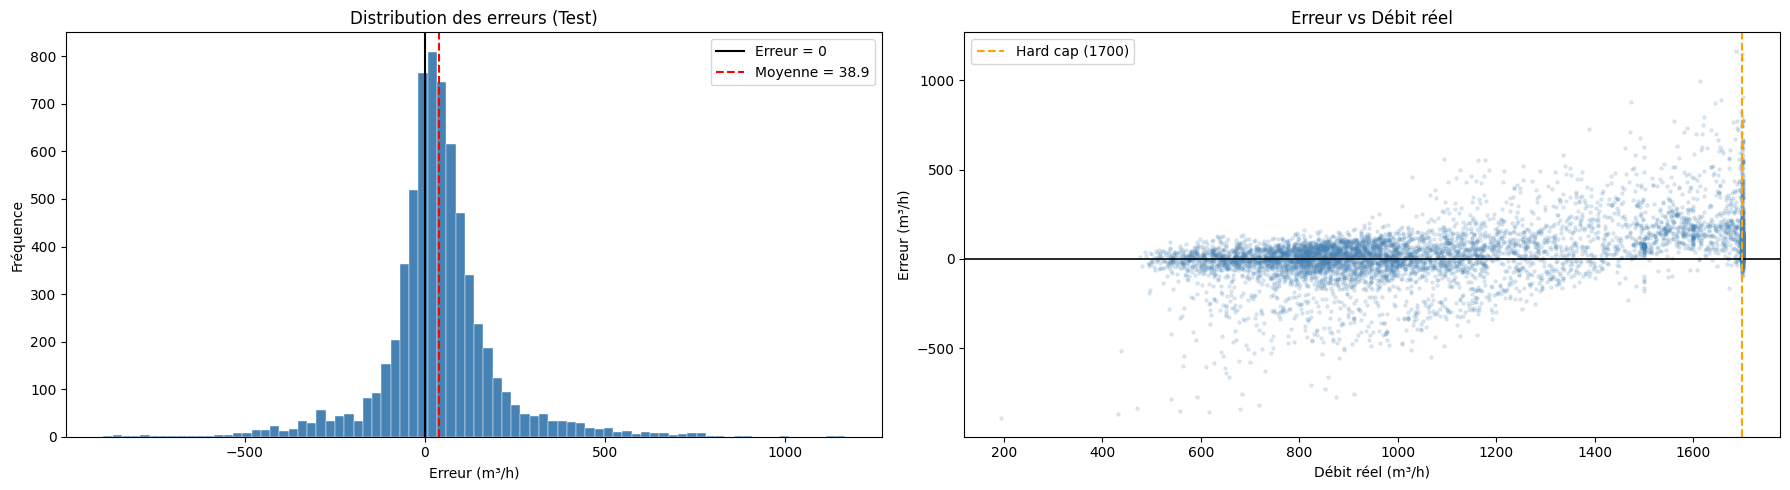


Erreur moyenne (biais)   : 38.90 m³/h
Erreur std               : 162.19 m³/h
% erreurs > 200 m³/h    : 14.7%
% erreurs > 100 m³/h    : 35.1%
% erreurs < 50 m³/h     : 39.9%


In [21]:
# Distribution des erreurs du modèle
errors = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Histogramme des erreurs
axes[0].hist(errors, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='black', linewidth=1.5, label='Erreur = 0')
axes[0].axvline(errors.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Moyenne = {errors.mean():.1f}')
axes[0].set_title('Distribution des erreurs (Test)')
axes[0].set_xlabel('Erreur (m³/h)')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Erreurs en fonction du débit réel (révèle les biais)
axes[1].scatter(y_test, errors, alpha=0.15, s=5, color='steelblue')
axes[1].axhline(0, color='black', linewidth=1.2)
axes[1].axvline(1700, color='orange', linestyle='--', linewidth=1.5, label='Hard cap (1700)')
axes[1].set_title('Erreur vs Débit réel')
axes[1].set_xlabel('Débit réel (m³/h)')
axes[1].set_ylabel('Erreur (m³/h)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nErreur moyenne (biais)   : {errors.mean():.2f} m³/h")
print(f"Erreur std               : {errors.std():.2f} m³/h")
print(f"% erreurs > 200 m³/h    : {(np.abs(errors) > 200).mean()*100:.1f}%")
print(f"% erreurs > 100 m³/h    : {(np.abs(errors) > 100).mean()*100:.1f}%")
print(f"% erreurs < 50 m³/h     : {(np.abs(errors) < 50).mean()*100:.1f}%")

Il faut ne pas oublier de calculer la standard deviation (demandé par l'organisatrice de capstone).
Essayer la std des différents splits.

In [22]:
# ── Métriques finales avec std (bootstrap sur le test) ───────────────────────
def bootstrap_metrics(y_true, y_pred, n_bootstrap=500, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    rmses, maes, r2s = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        rmses.append(np.sqrt(mean_squared_error(y_true.iloc[idx], y_pred[idx])))
        maes.append(mean_absolute_error(y_true.iloc[idx], y_pred[idx]))
        r2s.append(r2_score(y_true.iloc[idx], y_pred[idx]))
    return {
        'RMSE': (np.mean(rmses), np.std(rmses)),
        'MAE':  (np.mean(maes),  np.std(maes)),
        'R²':   (np.mean(r2s),   np.std(r2s))
    }

print(f"\n── Métriques finales avec intervalle de confiance (bootstrap 500) ──")
for label, y_true, y_pred in [
    ("Train",      y_train,  y_pred_train),
    ("Validation", y_val,    y_pred_val),
    ("Test",       y_test,   y_pred_test),
]:
    stats = bootstrap_metrics(y_true, y_pred)
    print(f"{label:12s} → "
          f"RMSE={stats['RMSE'][0]:.2f} ± {stats['RMSE'][1]:.2f} | "
          f"MAE={stats['MAE'][0]:.2f} ± {stats['MAE'][1]:.2f} | "
          f"R²={stats['R²'][0]:.3f} ± {stats['R²'][1]:.3f}")


── Métriques finales avec intervalle de confiance (bootstrap 500) ──
Train        → RMSE=141.22 ± 1.80 | MAE=83.03 ± 0.81 | R²=0.849 ± 0.004
Validation   → RMSE=169.81 ± 2.89 | MAE=104.87 ± 1.68 | R²=0.860 ± 0.005
Test         → RMSE=166.96 ± 2.82 | MAE=108.28 ± 1.51 | R²=0.803 ± 0.007


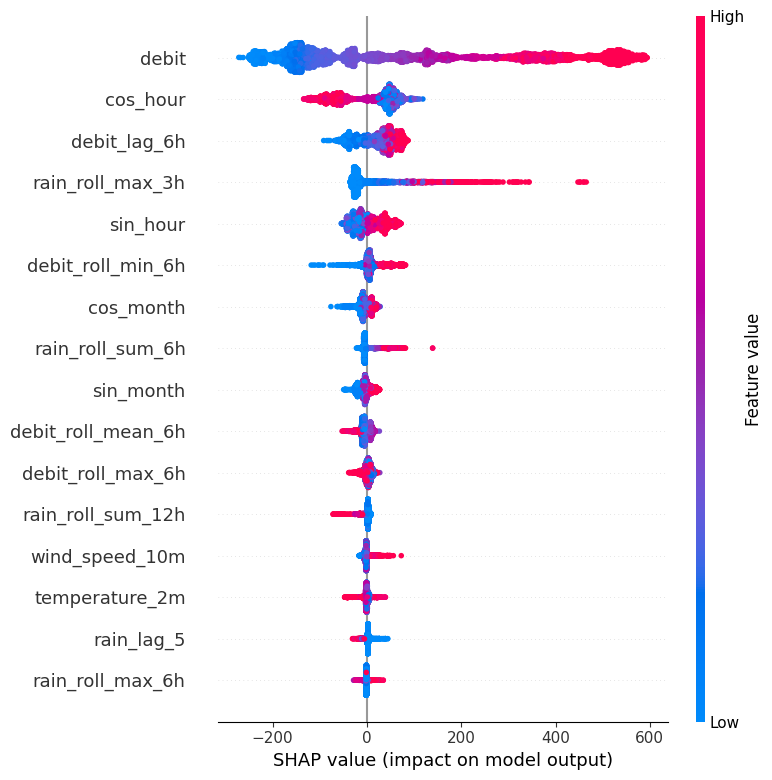

In [23]:
# SHAP pour l'importance des features sur la prédiction
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Résumé global
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# Impact de chaque feature sur une prédiction individuelle
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])

#### Feature engineering sur la pluie 

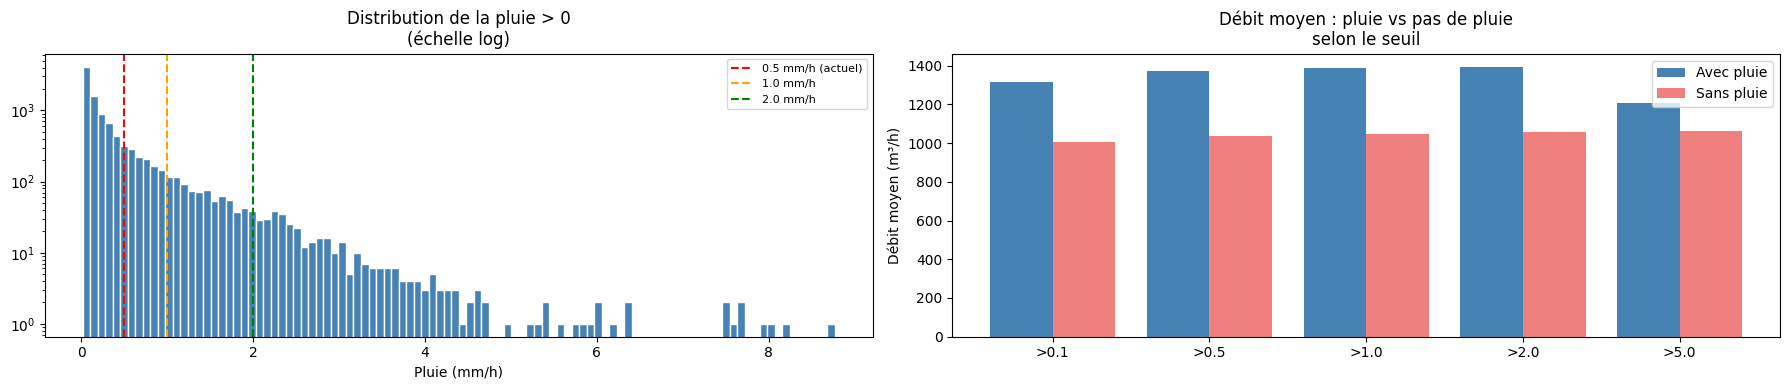

── Distribution de la pluie ──
  % heures sans pluie (=0)   : 69.3%
  % heures pluie > 0.1 mm/h  : 18.3%
  % heures pluie > 0.5 mm/h  : 7.0%
  % heures pluie > 1.0 mm/h  : 3.5%
  % heures pluie > 2.0 mm/h  : 1.1%
  Percentile 75 (pluie > 0)  : 0.45 mm/h
  Percentile 90 (pluie > 0)  : 1.11 mm/h
  Percentile 95 (pluie > 0)  : 1.71 mm/h


In [24]:
# ── Explorer la distribution de la pluie pour choisir un seuil pertinent ─────
rain_all = df_3h['rain']

fig, axes = plt.subplots(1, 2, figsize=(18, 4))

# 1. Distribution brute (log scale pour voir les petites valeurs)
axes[0].hist(rain_all[rain_all > 0], bins=100, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_xlabel('Pluie (mm/h)')
axes[0].set_title('Distribution de la pluie > 0\n(échelle log)')
axes[0].axvline(0.5, color='red',    linestyle='--', label='0.5 mm/h (actuel)')
axes[0].axvline(1.0, color='orange', linestyle='--', label='1.0 mm/h')
axes[0].axvline(2.0, color='green',  linestyle='--', label='2.0 mm/h')
axes[0].legend(fontsize=8)

# Débit moyen selon que la pluie dépasse le seuil ou non
seuils_test = [0.1, 0.5, 1.0, 2.0, 5.0]
debit_on  = [df_3h.loc[df_3h['rain'] >  s, 'debit'].mean() for s in seuils_test]
debit_off = [df_3h.loc[df_3h['rain'] <= s, 'debit'].mean() for s in seuils_test]
x = np.arange(len(seuils_test))
axes[1].bar(x - 0.2, debit_on,  0.4, label='Avec pluie',  color='steelblue')
axes[1].bar(x + 0.2, debit_off, 0.4, label='Sans pluie',  color='lightcoral')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'>{s}' for s in seuils_test])
axes[1].set_ylabel('Débit moyen (m³/h)')
axes[1].set_title('Débit moyen : pluie vs pas de pluie\nselon le seuil')
axes[1].legend()

plt.tight_layout()
plt.show()

# Stats rapides
print("── Distribution de la pluie ──")
print(f"  % heures sans pluie (=0)   : {(rain_all == 0).mean()*100:.1f}%")
print(f"  % heures pluie > 0.1 mm/h  : {(rain_all > 0.1).mean()*100:.1f}%")
print(f"  % heures pluie > 0.5 mm/h  : {(rain_all > 0.5).mean()*100:.1f}%")
print(f"  % heures pluie > 1.0 mm/h  : {(rain_all > 1.0).mean()*100:.1f}%")
print(f"  % heures pluie > 2.0 mm/h  : {(rain_all > 2.0).mean()*100:.1f}%")
print(f"  Percentile 75 (pluie > 0)  : {rain_all[rain_all > 0].quantile(0.75):.2f} mm/h")
print(f"  Percentile 90 (pluie > 0)  : {rain_all[rain_all > 0].quantile(0.90):.2f} mm/h")
print(f"  Percentile 95 (pluie > 0)  : {rain_all[rain_all > 0].quantile(0.95):.2f} mm/h")

Obs avec pluie (test)    : 107 (1.6%)
Obs sans pluie (test)    : 6566 (98.4%)


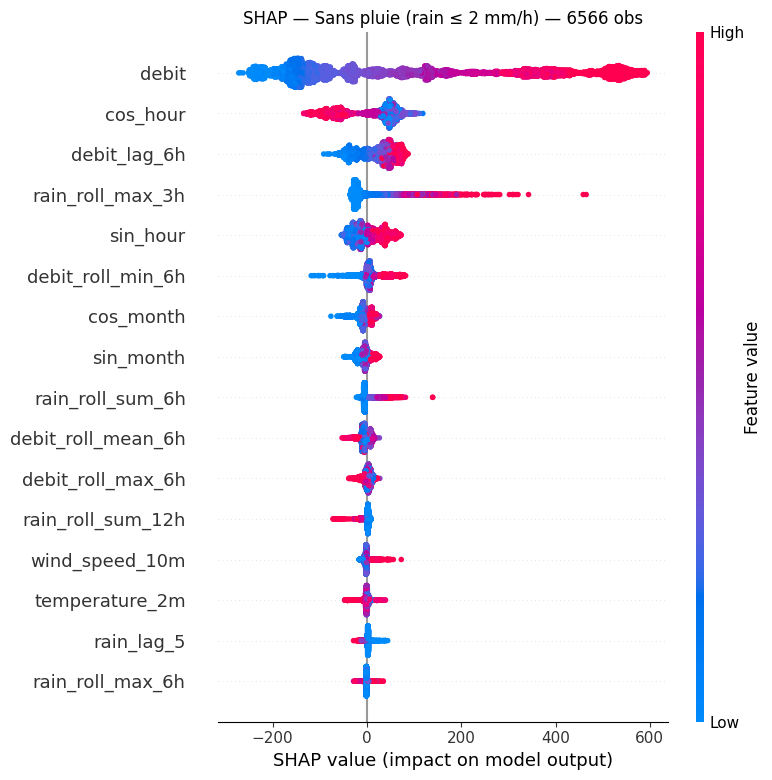

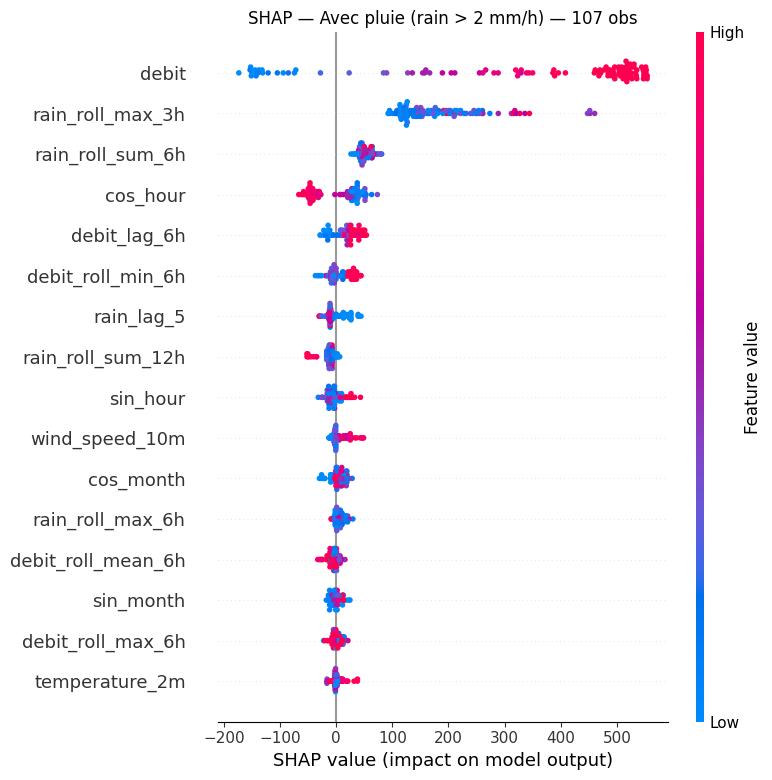

In [25]:
SEUIL_PLUIE = 2  # mm/h

rain_on_test  = df_3h.loc[X_test.index, 'rain'] > SEUIL_PLUIE
rain_off_test = df_3h.loc[X_test.index, 'rain'] <= SEUIL_PLUIE

print(f"Obs avec pluie (test)    : {rain_on_test.sum()} ({rain_on_test.mean()*100:.1f}%)")
print(f"Obs sans pluie (test)    : {rain_off_test.sum()} ({rain_off_test.mean()*100:.1f}%)")

explainer_3h     = shap.TreeExplainer(model)
shap_values_test = explainer_3h.shap_values(X_test)

# SHAP Sans pluie 
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_test[rain_off_test.values],
    X_test[rain_off_test.values],
    show=False
)
plt.title(f'SHAP — Sans pluie (rain ≤ {SEUIL_PLUIE} mm/h) — {rain_off_test.sum()} obs', fontsize=12)
plt.tight_layout()
plt.show()

# SHAP Avec pluie
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_test[rain_on_test.values],
    X_test[rain_on_test.values],
    show=False
)
plt.title(f'SHAP — Avec pluie (rain > {SEUIL_PLUIE} mm/h) — {rain_on_test.sum()} obs', fontsize=12)
plt.tight_layout()
plt.show()

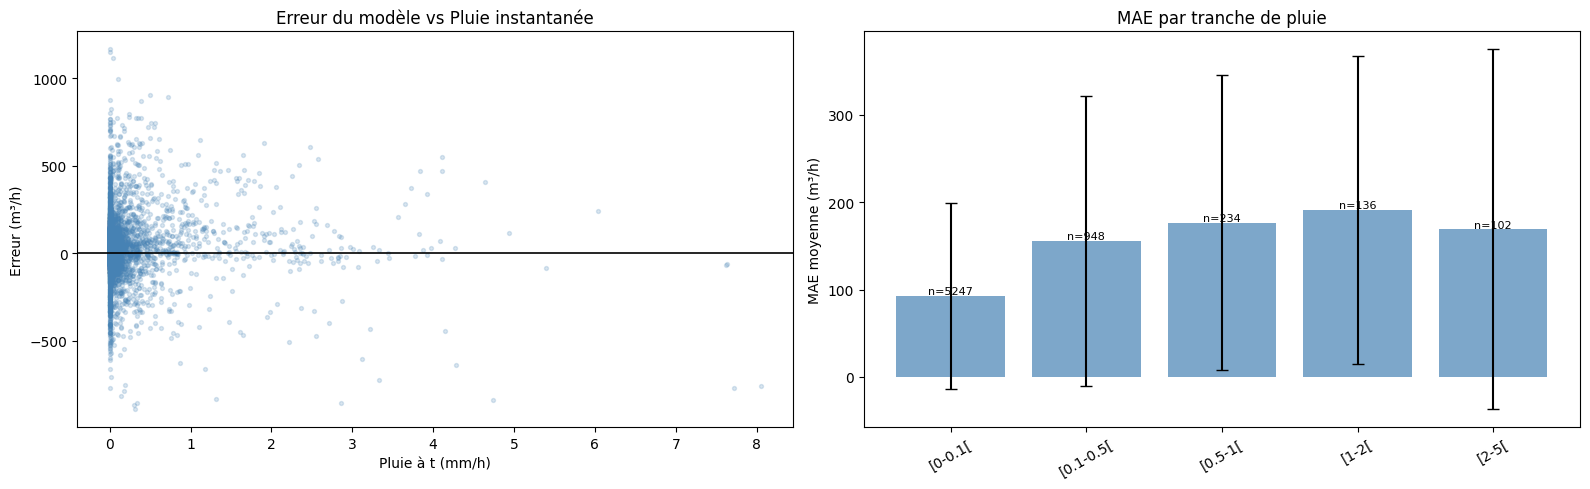


Corrélation pluie ↔ |erreur| : 0.178


In [26]:
# Corrélation entre pluie et erreur du modèle
errors_test = y_test.values - y_pred_test
rain_test_vals = df_3h.loc[X_test.index, 'rain'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter erreur vs pluie
axes[0].scatter(rain_test_vals, errors_test, alpha=0.2, s=8, color='steelblue')
axes[0].axhline(0, color='black', linewidth=1.2)
axes[0].set_xlabel('Pluie à t (mm/h)')
axes[0].set_ylabel('Erreur (m³/h)')
axes[0].set_title('Erreur du modèle vs Pluie instantanée')

# Erreur moyenne par tranche de pluie
tranches_pluie = [0, 0.1, 0.5, 1, 2, 5, 10, 100]
labels, mean_err, std_err, counts = [], [], [], []
for low, high in zip(tranches_pluie[:-1], tranches_pluie[1:]):
    mask = (rain_test_vals >= low) & (rain_test_vals < high)
    if mask.sum() > 10:
        labels.append(f'[{low}-{high}[')
        mean_err.append(np.mean(np.abs(errors_test[mask])))
        std_err.append(np.std(np.abs(errors_test[mask])))
        counts.append(mask.sum())

x = np.arange(len(labels))
axes[1].bar(x, mean_err, yerr=std_err, color='steelblue', alpha=0.7, capsize=4)
for i, (m, c) in enumerate(zip(mean_err, counts)):
    axes[1].text(i, m + 2, f'n={c}', ha='center', fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30)
axes[1].set_ylabel('MAE moyenne (m³/h)')
axes[1].set_title('MAE par tranche de pluie')

plt.tight_layout()
plt.show()

corr = np.corrcoef(rain_test_vals, np.abs(errors_test))[0, 1]
print(f"\nCorrélation pluie ↔ |erreur| : {corr:.3f}")

Bilan de toute l'étude: le modèle semble faire de l'inertie hydraulique, pas de la prévision pluie.

### Amélioration modèle 3h

Train      : 2021-01-02 → 2023-06-23  (20,016 obs)
Validation : 2023-06-23 → 2024-03-27  (6,672 obs)
Test       : 2024-03-27 → 2024-12-31  (6,673 obs)

── Modèle v1 (baseline) ──
Train        → RMSE=141.20 | MAE=83.01 | R²=0.850
Validation   → RMSE=169.82 | MAE=104.85 | R²=0.860
Test         → RMSE=166.79 | MAE=108.18 | R²=0.804

── Modèle v2 (lags pluie + épisode) ──
Train        → RMSE=140.25 | MAE=82.43 | R²=0.852
Validation   → RMSE=168.42 | MAE=104.10 | R²=0.862
Test         → RMSE=166.24 | MAE=108.08 | R²=0.805

── Erreur sur épisodes pluvieux (rain > 2.0 mm/h) ──
v1 pluie     → RMSE=281.70 | MAE=179.63 | R²=0.247
v2 pluie     → RMSE=279.64 | MAE=178.40 | R²=0.258

── Modèle v1 (baseline) ──
Train        → RMSE=141.20 | MAE=83.01 | R²=0.850
Validation   → RMSE=169.82 | MAE=104.85 | R²=0.860
Test         → RMSE=166.79 | MAE=108.18 | R²=0.804

── Modèle v2 (lags pluie + épisode) ──
Train        → RMSE=140.25 | MAE=82.43 | R²=0.852
Validation   → RMSE=168.42 | MAE=104.10 | R²=0.862


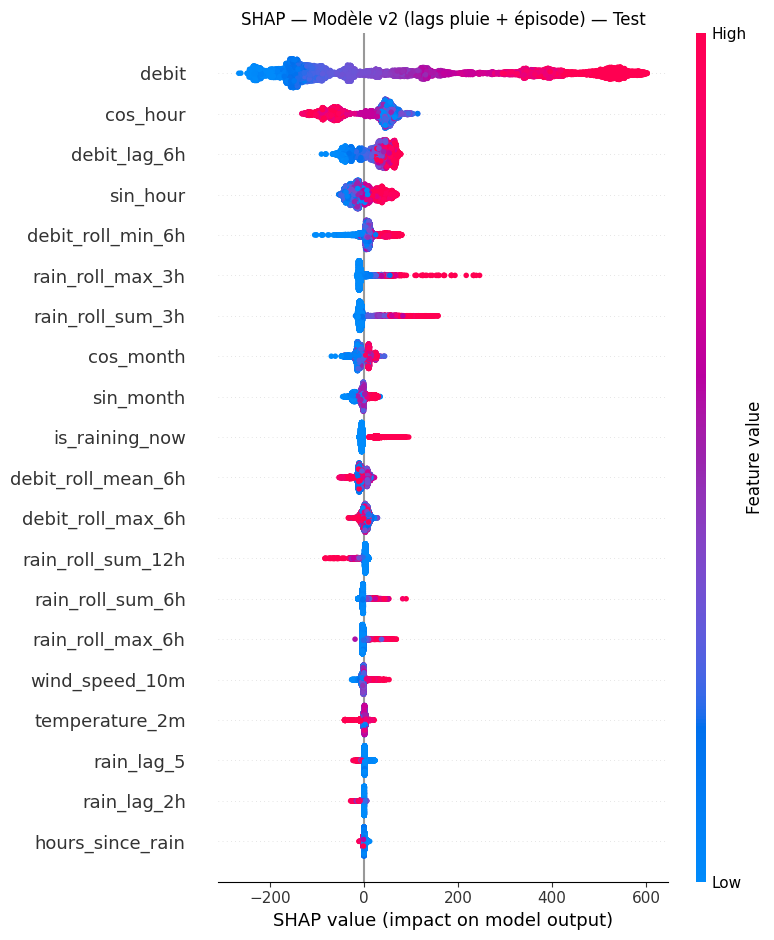

In [13]:
# lags courts pluie + features épisode pluvieux

df_3h_v2 = df_3h.copy()

# Lags courts de la pluie
for lag in [1, 2, 3, 4]:
    df_3h_v2[f'rain_lag_{lag}h'] = df_3h_v2['rain'].shift(lag)

# Features d'épisode pluvieux
df_3h_v2['rain_roll_sum_3h']  = df_3h_v2['rain'].rolling(window=3,  min_periods=1).sum()
df_3h_v2['rain_roll_sum_6h_v2']  = df_3h_v2['rain'].rolling(window=6,  min_periods=1).sum()


# Durée depuis la dernière pluie (en heures)
is_raining = (df_3h_v2['rain'] > 0.1).astype(int)
# Compteur d'heures depuis dernière pluie
hours_since_rain = []
counter = 0
for val in is_raining:
    if val == 1:
        counter = 0
    else:
        counter += 1
    hours_since_rain.append(counter)
df_3h_v2['hours_since_rain'] = hours_since_rain

# Flag épisode en cours
df_3h_v2['is_raining_now'] = (df_3h_v2['rain'] > 0.1).astype(int)

# Supprimer NaN
df_3h_v2 = df_3h_v2.dropna()

feature_cols_3h_v2 = [
    'debit',
    # Météo
    'temperature_2m', 'wind_speed_10m',
    # Pluie — lags courts (nouveau)
    'rain_lag_1h', 'rain_lag_2h', 'rain_lag_3h', 'rain_lag_4h', 'rain_lag_5',
    # Pluie — rolling
    'rain_roll_sum_3h', 'rain_roll_sum_6h', 'rain_roll_sum_12h',
    'rain_roll_max_3h', 'rain_roll_max_6h',
    # Épisode pluvieux (nouveau)
    'is_raining_now', 'hours_since_rain',
    # Temporel
    'sin_hour', 'cos_hour', 'sin_month', 'cos_month',
    # Débit passé
    'debit_lag_6h', 'debit_roll_mean_6h',
    'debit_roll_max_6h', 'debit_roll_min_6h',
]

X_v2 = df_3h_v2[feature_cols_3h_v2]
y_v2 = df_3h_v2['debit_target_3h']

# Split (60/20/20)
n = len(X_v2)
n_train = int(n * 0.60)
n_val   = int(n * 0.20)

X_train_v2 = X_v2.iloc[:n_train];           y_train_v2 = y_v2.iloc[:n_train]
X_val_v2   = X_v2.iloc[n_train:n_train+n_val]; y_val_v2 = y_v2.iloc[n_train:n_train+n_val]
X_test_v2  = X_v2.iloc[n_train+n_val:];     y_test_v2  = y_v2.iloc[n_train+n_val:]

print(f"Train      : {X_train_v2.index.min().date()} → {X_train_v2.index.max().date()}  ({len(X_train_v2):,} obs)")
print(f"Validation : {X_val_v2.index.min().date()} → {X_val_v2.index.max().date()}  ({len(X_val_v2):,} obs)")
print(f"Test       : {X_test_v2.index.min().date()} → {X_test_v2.index.max().date()}  ({len(X_test_v2):,} obs)")

# Entraînement
model_v2 = xgb.XGBRegressor(
    max_depth=3, n_estimators=300, learning_rate=0.05,
    reg_alpha=1.0, reg_lambda=5.0,
    random_state=42
)
model_v2.fit(X_train_v2, y_train_v2)

y_pred_train_v2 = model_v2.predict(X_train_v2)
y_pred_val_v2   = model_v2.predict(X_val_v2)
y_pred_test_v2  = model_v2.predict(X_test_v2)

# Comparaison v1 vs v2 
print("\n── Modèle v1 (baseline) ──")
print_metrics("Train",      y_train, y_pred_train)
print_metrics("Validation", y_val,   y_pred_val)
print_metrics("Test",       y_test,  y_pred_test)

print("\n── Modèle v2 (lags pluie + épisode) ──")
print_metrics("Train",      y_train_v2, y_pred_train_v2)
print_metrics("Validation", y_val_v2,   y_pred_val_v2)
print_metrics("Test",       y_test_v2,  y_pred_test_v2)

# Focus sur les épisodes pluvieux 
SEUIL = 2.0  # mm/h
rain_mask_test = df_3h_v2.loc[X_test_v2.index, 'rain'] > SEUIL

print(f"\n── Erreur sur épisodes pluvieux (rain > {SEUIL} mm/h) ──")
if rain_mask_test.sum() > 0:
    print_metrics("v1 pluie", 
                  y_test[y_test.index.isin(X_test_v2.index[rain_mask_test])],
                  y_pred_test[np.where(np.isin(X_test.index, X_test_v2.index[rain_mask_test]))[0]])
    print_metrics("v2 pluie", 
                  y_test_v2[rain_mask_test.values],
                  y_pred_test_v2[rain_mask_test.values])

# SHAP v2 
explainer_v2    = shap.TreeExplainer(model_v2)
shap_values_v2  = explainer_v2.shap_values(X_test_v2)

shap.summary_plot(shap_values_v2, X_test_v2, show=False)
plt.title("SHAP — Modèle v2 (lags pluie + épisode) — Test")
plt.tight_layout()
plt.show()

### Modèle simple à 3h avec normalisation 

── Modèle de base (sans normalisation) ──
Train        → RMSE=149.85 | MAE=88.49 | R²=0.831
Validation   → RMSE=175.55 | MAE=109.20 | R²=0.850
Test         → RMSE=171.73 | MAE=113.39 | R²=0.792


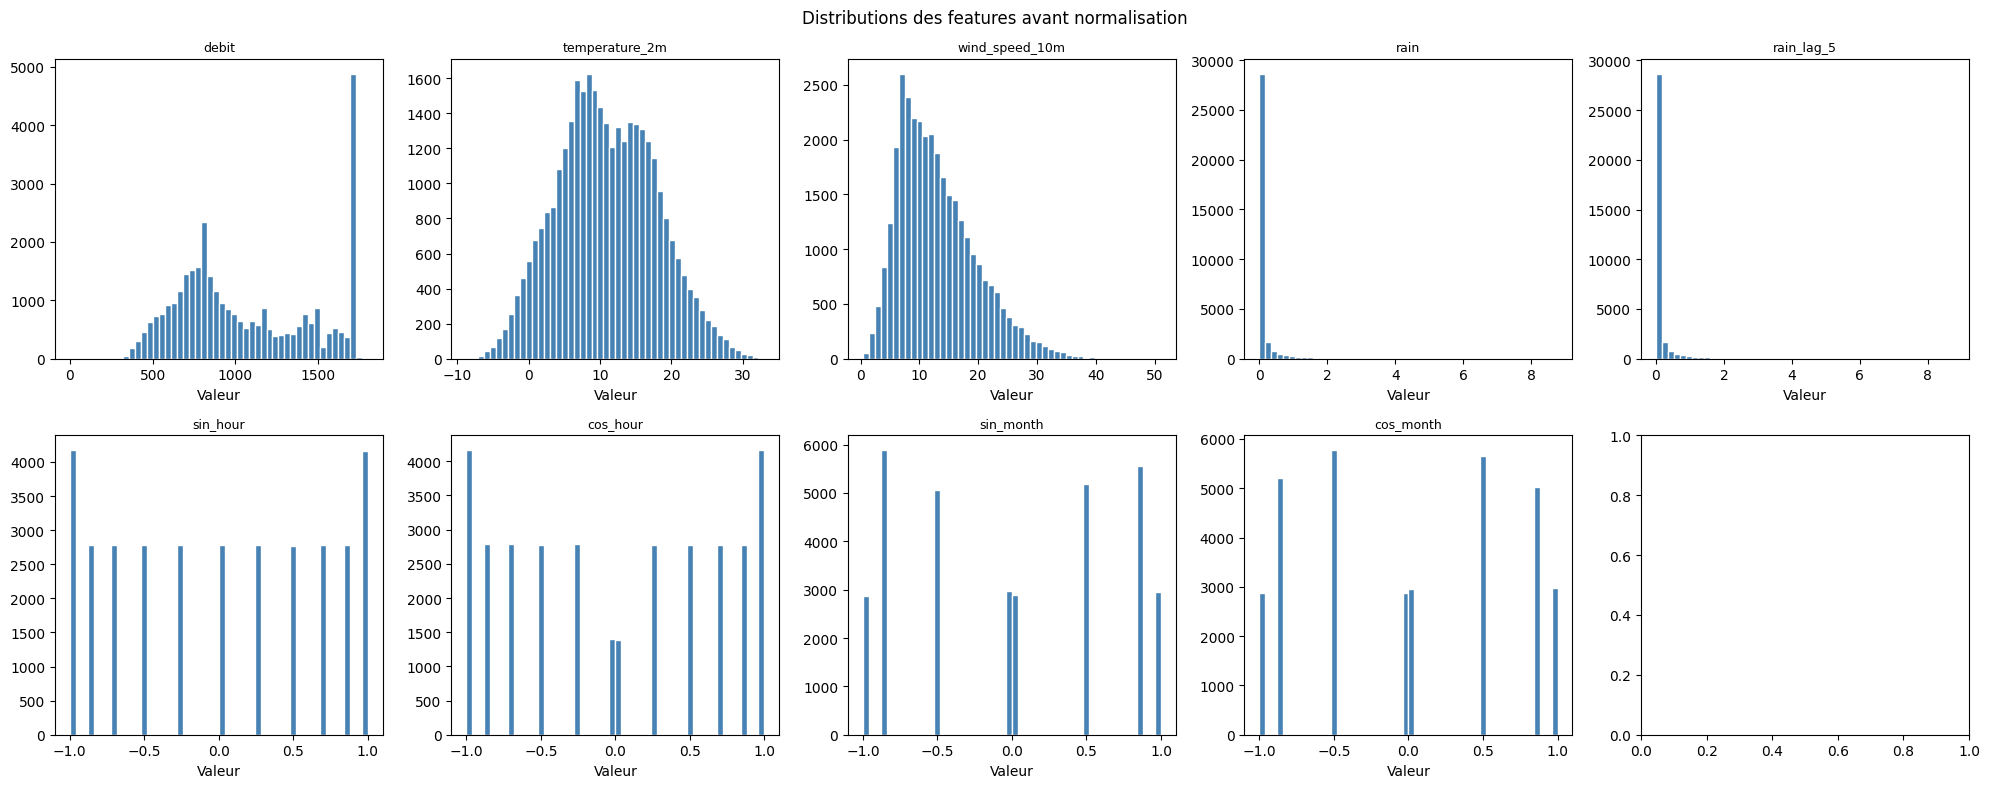

In [7]:
# Jeu de données avec les variables sélectionnées et split
df_v3 = df_3h.copy()

# Features de base uniquement
feature_cols_base = [
    'debit',            # débit à t (point de départ)
    'temperature_2m',   # température
    'wind_speed_10m',   # vent
    'rain',             # pluie à t
    'rain_lag_5',       # pluie décalée 5h
    'sin_hour',         # encodage cyclique heure
    'cos_hour',
    'sin_month',        # encodage cyclique mois
    'cos_month',
]

df_v3 = df_v3.dropna(subset=feature_cols_base + ['debit_target_3h'])

X_base = df_v3[feature_cols_base]
y_base = df_v3['debit_target_3h']

# Split 60/20/20
n = len(X_base)
n_train = int(n * 0.60)
n_val   = int(n * 0.20)

X_train_b = X_base.iloc[:n_train]
y_train_b = y_base.iloc[:n_train]
X_val_b   = X_base.iloc[n_train:n_train+n_val]
y_val_b   = y_base.iloc[n_train:n_train+n_val]
X_test_b  = X_base.iloc[n_train+n_val:]
y_test_b  = y_base.iloc[n_train+n_val:]

model_base = xgb.XGBRegressor(
    max_depth=3, n_estimators=300, learning_rate=0.05,
    reg_alpha=1.0, reg_lambda=5.0, random_state=42
)
model_base.fit(X_train_b, y_train_b)

y_pred_train_b = model_base.predict(X_train_b)
y_pred_val_b   = model_base.predict(X_val_b)
y_pred_test_b  = model_base.predict(X_test_b)

print("── Modèle de base (sans normalisation) ──")
print_metrics("Train",      y_train_b, y_pred_train_b)
print_metrics("Validation", y_val_b,   y_pred_val_b)
print_metrics("Test",       y_test_b,  y_pred_test_b)

# Distribution des features pour choisir la normalisation
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(feature_cols_base):
    axes[i//5][i%5].hist(X_base[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i//5][i%5].set_title(col, fontsize=9)
    axes[i//5][i%5].set_xlabel('Valeur')
plt.suptitle('Distributions des features avant normalisation', fontsize=12)
plt.tight_layout()
plt.show()

#### Normalisation des features

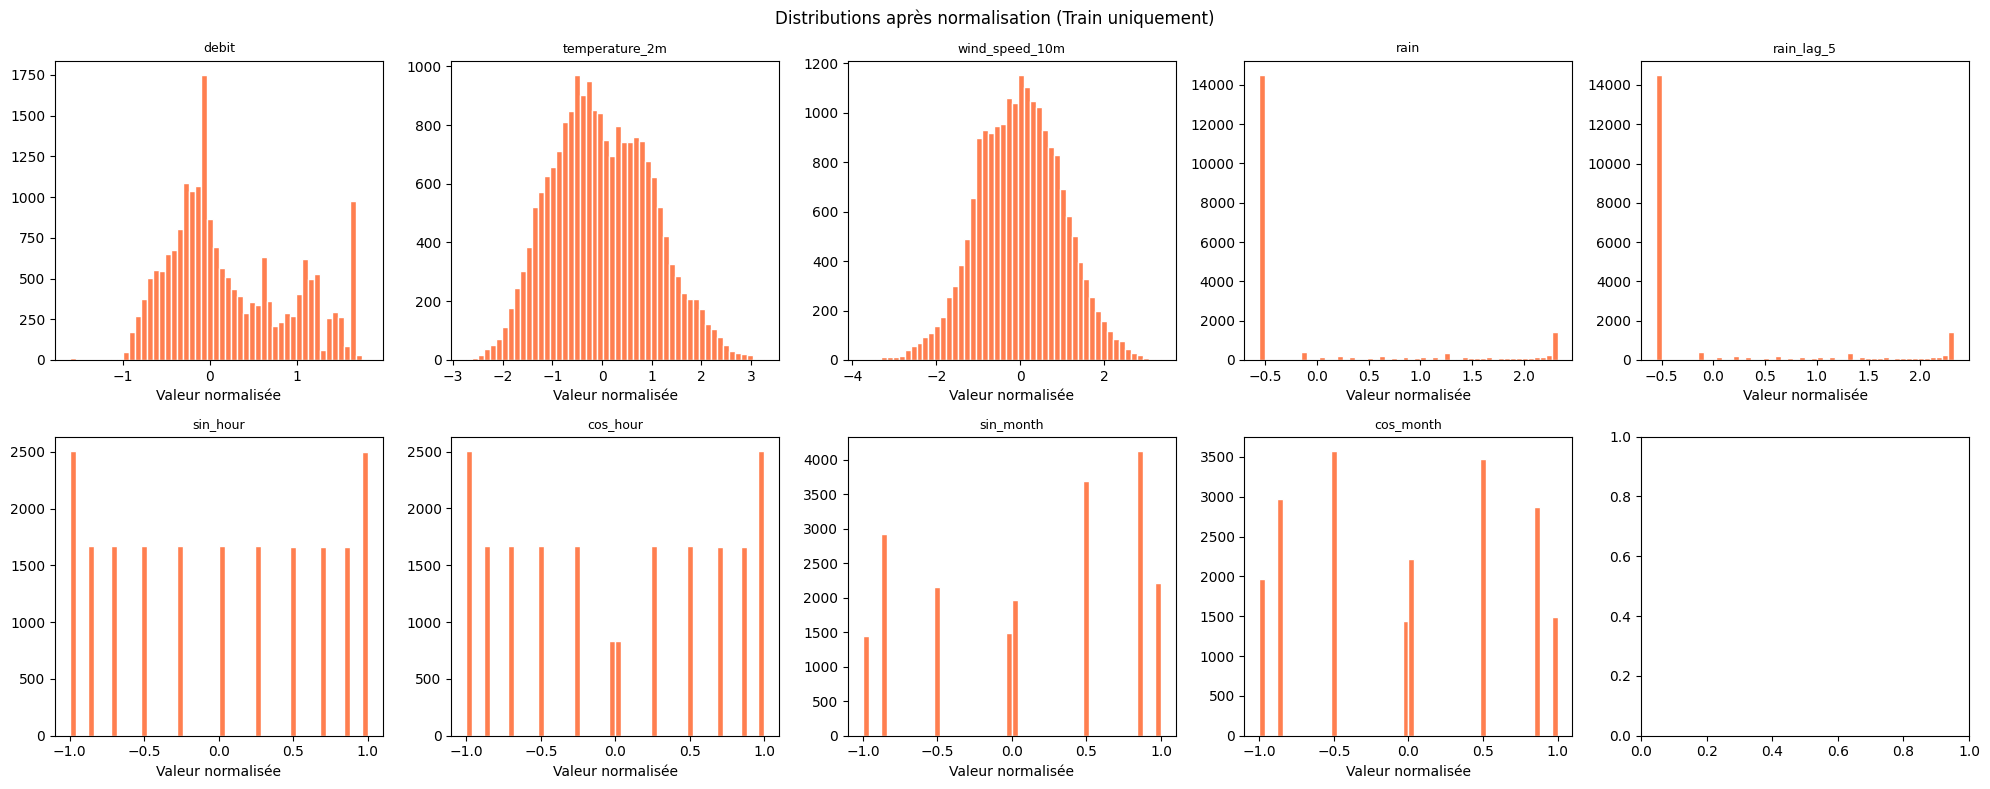

── Comparaison : sans vs avec normalisation ──

Sans normalisation :
  Train      → RMSE=149.85 | MAE=88.49 | R²=0.831
  Validation → RMSE=175.55 | MAE=109.20 | R²=0.850
  Test       → RMSE=171.73 | MAE=113.39 | R²=0.792

Avec normalisation :
  Train      → RMSE=149.83 | MAE=88.57 | R²=0.831
  Validation → RMSE=175.21 | MAE=108.69 | R²=0.851
  Test       → RMSE=172.06 | MAE=113.77 | R²=0.791


In [8]:
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer


normalisation_map = {
    'debit':          RobustScaler(),      # bimodale + hard cap → robuste aux outliers
    'temperature_2m': StandardScaler(),    # gaussienne → z-score
    'wind_speed_10m': PowerTransformer(),  # asymétrique droite → Yeo-Johnson
    'rain':           PowerTransformer(),  # pic en 0 + queue droite → Yeo-Johnson
    'rain_lag_5':     PowerTransformer(),  # idem
    # sin/cos : pas de transformation
}

cols_no_transform = ['sin_hour', 'cos_hour', 'sin_month', 'cos_month']


X_train_norm = X_train_b.copy()
X_val_norm   = X_val_b.copy()
X_test_norm  = X_test_b.copy()

fitted_scalers = {}
for col, scaler in normalisation_map.items():
    scaler.fit(X_train_b[[col]])
    X_train_norm[col] = scaler.transform(X_train_b[[col]])
    X_val_norm[col]   = scaler.transform(X_val_b[[col]])
    X_test_norm[col]  = scaler.transform(X_test_b[[col]])
    fitted_scalers[col] = scaler  # sauvegarde pour inférence future

# Vérification visuelle après normalisation
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(feature_cols_base):
    axes[i//5][i%5].hist(X_train_norm[col].dropna(), bins=50, color='coral', edgecolor='white')
    axes[i//5][i%5].set_title(f'{col}', fontsize=9)
    axes[i//5][i%5].set_xlabel('Valeur normalisée')
plt.suptitle('Distributions après normalisation (Train uniquement)', fontsize=12)
plt.tight_layout()
plt.show()

# Entraînement avec normalisation
model_norm = xgb.XGBRegressor(
    max_depth=3, n_estimators=300, learning_rate=0.05,
    reg_alpha=1.0, reg_lambda=5.0, random_state=42
)
model_norm.fit(X_train_norm, y_train_b)

y_pred_train_n = model_norm.predict(X_train_norm)
y_pred_val_n   = model_norm.predict(X_val_norm)
y_pred_test_n  = model_norm.predict(X_test_norm)

print("── Comparaison : sans vs avec normalisation ──")
print("\nSans normalisation :")
print_metrics("  Train",      y_train_b, y_pred_train_b)
print_metrics("  Validation", y_val_b,   y_pred_val_b)
print_metrics("  Test",       y_test_b,  y_pred_test_b)
print("\nAvec normalisation :")
print_metrics("  Train",      y_train_b, y_pred_train_n)
print_metrics("  Validation", y_val_b,   y_pred_val_n)
print_metrics("  Test",       y_test_b,  y_pred_test_n)

Un test a été effectué avec une Ridge regression mais aucune amélioration n'a été constatée. 

### Ajout des transformations des features pluie

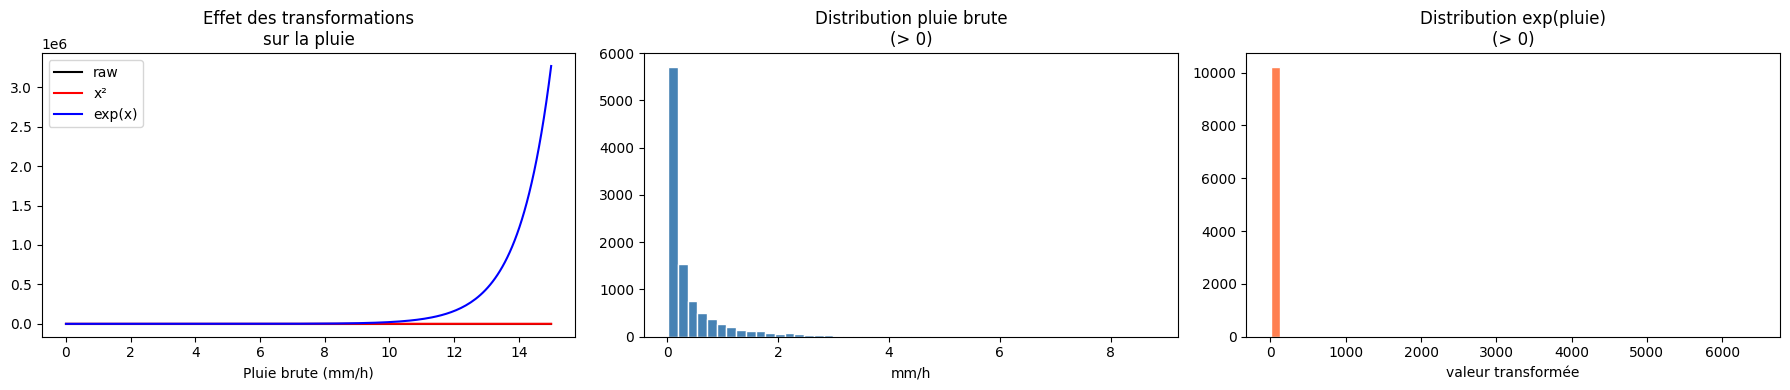


── Comparaison des 3 étapes ──
Base (sans normalisation) :
  Test       → RMSE=171.73 | MAE=113.39 | R²=0.792
Base + normalisation :
  Test       → RMSE=172.06 | MAE=113.77 | R²=0.791
Base + normalisation + transformations pluie :
  Test       → RMSE=171.85 | MAE=113.40 | R²=0.791


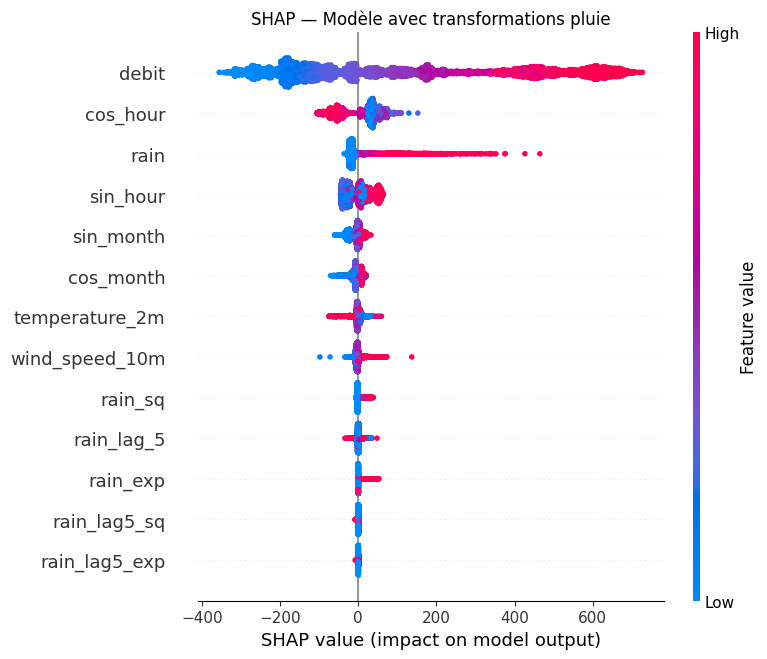

In [9]:
df_v3_rain = df_v3.copy()


df_v3_rain['rain_sq']      = df_v3_rain['rain'] ** 2                          # effet quadratique
df_v3_rain['rain_exp']     = np.exp(df_v3_rain['rain'])                       # effet exponentiel
df_v3_rain['rain_lag5_sq'] = df_v3_rain['rain_lag_5'] ** 2
df_v3_rain['rain_lag5_exp']= np.exp(df_v3_rain['rain_lag_5'])

# Visualisation de l'effet de la transformation
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
rain_vals = np.linspace(0, 15, 200)
axes[0].plot(rain_vals, rain_vals,        label='raw',        color='black')
axes[0].plot(rain_vals, rain_vals**2,     label='x²',         color='red')
axes[0].plot(rain_vals, np.exp(rain_vals), label='exp(x)', color='blue')
axes[0].set_title('Effet des transformations\nsur la pluie')
axes[0].set_xlabel('Pluie brute (mm/h)')
axes[0].legend()

# Distribution brute vs transformée
axes[1].hist(df_v3_rain['rain'][df_v3_rain['rain'] > 0], bins=50,
             color='steelblue', edgecolor='white')
axes[1].set_title('Distribution pluie brute\n(> 0)')
axes[1].set_xlabel('mm/h')

axes[2].hist(df_v3_rain['rain_exp'][df_v3_rain['rain'] > 0], bins=50,
             color='coral', edgecolor='white')
axes[2].set_title('Distribution exp(pluie)\n(> 0)')
axes[2].set_xlabel('valeur transformée')

plt.tight_layout()
plt.show()

feature_cols_rain = feature_cols_base + [
    'rain_sq', 'rain_exp',
    'rain_lag5_sq', 'rain_lag5_exp',
]

df_v3_rain = df_v3_rain.dropna(subset=feature_cols_rain + ['debit_target_3h'])
X_rain = df_v3_rain[feature_cols_rain]
y_rain = df_v3_rain['debit_target_3h']

n = len(X_rain)
n_train, n_val = int(n*0.6), int(n*0.2)

X_tr_r = X_rain.iloc[:n_train];              y_tr_r = y_rain.iloc[:n_train]
X_va_r = X_rain.iloc[n_train:n_train+n_val]; y_va_r = y_rain.iloc[n_train:n_train+n_val]
X_te_r = X_rain.iloc[n_train+n_val:];        y_te_r = y_rain.iloc[n_train+n_val:]

# Normalisation 
transformers_rain = {
    #'debit':          RobustScaler(),
    'temperature_2m': StandardScaler(),
    'wind_speed_10m': PowerTransformer(),
    'rain':           PowerTransformer(),
    'rain_lag_5':     PowerTransformer(),
    'rain_sq':        PowerTransformer(),
    'rain_exp':       PowerTransformer(),
    'rain_lag5_sq':   PowerTransformer(),
    'rain_lag5_exp':  PowerTransformer(),
}

X_tr_rn, X_va_rn, X_te_rn = X_tr_r.copy(), X_va_r.copy(), X_te_r.copy()
for col, scaler in transformers_rain.items():
    scaler.fit(X_tr_r[[col]])
    X_tr_rn[col] = scaler.transform(X_tr_r[[col]])
    X_va_rn[col] = scaler.transform(X_va_r[[col]])
    X_te_rn[col] = scaler.transform(X_te_r[[col]])

model_rain = xgb.XGBRegressor(
    max_depth=3, n_estimators=300, learning_rate=0.05,
    reg_alpha=1.0, reg_lambda=5.0, random_state=42
)
model_rain.fit(X_tr_rn, y_tr_r)

print("\n── Comparaison des 3 étapes ──")
print("Base (sans normalisation) :")
print_metrics("  Test", y_test_b, y_pred_test_b)
print("Base + normalisation :")
print_metrics("  Test", y_test_b, y_pred_test_n)
print("Base + normalisation + transformations pluie :")
print_metrics("  Test", y_te_r, model_rain.predict(X_te_rn))

# SHAP final
explainer_rain = shap.TreeExplainer(model_rain)
shap_values_rain = explainer_rain.shap_values(X_te_rn)
shap.summary_plot(shap_values_rain, X_te_rn, show=False)
plt.title("SHAP — Modèle avec transformations pluie")
plt.tight_layout()
plt.show()

## Recommandations tuteur — Amélioration du modèle

### Étape 1 : Augmenter la profondeur des arbres (max_depth)

Avec beaucoup de features, `max_depth=3` peut être insuffisant pour capturer les interactions.
On teste une grille de profondeurs sur le modèle v1 (baseline avec 15 features).

depth= 3 | Train R²=0.852  Val R²=0.862  Test R²=0.805  | Gap=0.047
depth= 4 | Train R²=0.876  Val R²=0.862  Test R²=0.801  | Gap=0.074
depth= 5 | Train R²=0.903  Val R²=0.860  Test R²=0.794  | Gap=0.109
depth= 6 | Train R²=0.929  Val R²=0.858  Test R²=0.789  | Gap=0.140
depth= 7 | Train R²=0.949  Val R²=0.856  Test R²=0.786  | Gap=0.163
depth= 8 | Train R²=0.967  Val R²=0.852  Test R²=0.780  | Gap=0.187
depth=10 | Train R²=0.989  Val R²=0.846  Test R²=0.778  | Gap=0.211


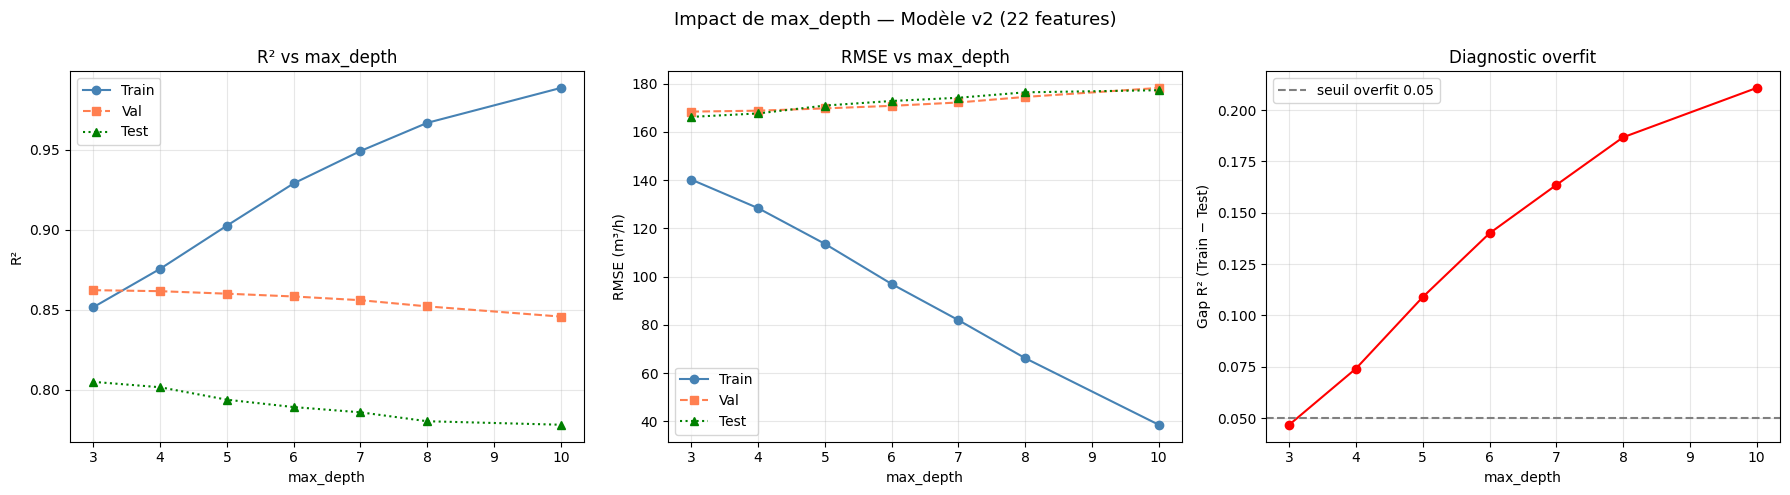


✅ Meilleur max_depth (R² test) : 3
   R² test = 0.805  |  RMSE test = 166.2  |  MAE test = 108.1
   Gap R² (train−test) = 0.047


In [14]:
# =====================================================================
# ÉTAPE 1 — Grille de max_depth sur le modèle v2 (meilleur actuel)
# =====================================================================
# On réutilise le même split et les mêmes features que v2

depths = [3, 4, 5, 6, 7, 8, 10]
results_depth = []

for d in depths:
    mdl = xgb.XGBRegressor(
        max_depth=d, n_estimators=300, learning_rate=0.05,
        reg_alpha=1.0, reg_lambda=5.0,
        random_state=42
    )
    mdl.fit(X_train_v2, y_train_v2)
    
    yp_tr = mdl.predict(X_train_v2)
    yp_va = mdl.predict(X_val_v2)
    yp_te = mdl.predict(X_test_v2)
    
    row = {
        'max_depth': d,
        'R2_train': r2_score(y_train_v2, yp_tr),
        'R2_val':   r2_score(y_val_v2, yp_va),
        'R2_test':  r2_score(y_test_v2, yp_te),
        'RMSE_train': np.sqrt(mean_squared_error(y_train_v2, yp_tr)),
        'RMSE_val':   np.sqrt(mean_squared_error(y_val_v2, yp_va)),
        'RMSE_test':  np.sqrt(mean_squared_error(y_test_v2, yp_te)),
        'MAE_train': mean_absolute_error(y_train_v2, yp_tr),
        'MAE_val':   mean_absolute_error(y_val_v2, yp_va),
        'MAE_test':  mean_absolute_error(y_test_v2, yp_te),
    }
    results_depth.append(row)
    print(f"depth={d:2d} | Train R²={row['R2_train']:.3f}  Val R²={row['R2_val']:.3f}  Test R²={row['R2_test']:.3f}  | Gap={row['R2_train']-row['R2_test']:.3f}")

df_depth = pd.DataFrame(results_depth)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R²
axes[0].plot(df_depth['max_depth'], df_depth['R2_train'], 'o-', label='Train', color='steelblue')
axes[0].plot(df_depth['max_depth'], df_depth['R2_val'],   's--', label='Val', color='coral')
axes[0].plot(df_depth['max_depth'], df_depth['R2_test'],  '^:', label='Test', color='green')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('R²')
axes[0].set_title('R² vs max_depth')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE
axes[1].plot(df_depth['max_depth'], df_depth['RMSE_train'], 'o-', label='Train', color='steelblue')
axes[1].plot(df_depth['max_depth'], df_depth['RMSE_val'],   's--', label='Val', color='coral')
axes[1].plot(df_depth['max_depth'], df_depth['RMSE_test'],  '^:', label='Test', color='green')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('RMSE (m³/h)')
axes[1].set_title('RMSE vs max_depth')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gap (overfit diagnostic)
axes[2].plot(df_depth['max_depth'], df_depth['R2_train'] - df_depth['R2_test'], 'o-', color='red')
axes[2].axhline(0.05, ls='--', color='gray', label='seuil overfit 0.05')
axes[2].set_xlabel('max_depth')
axes[2].set_ylabel('Gap R² (Train − Test)')
axes[2].set_title('Diagnostic overfit')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Impact de max_depth — Modèle v2 (22 features)', fontsize=13)
plt.tight_layout()
plt.show()

# Meilleur depth selon le compromis val/test
best_idx = df_depth['R2_test'].idxmax()
best_d = int(df_depth.loc[best_idx, 'max_depth'])
print(f"\n✅ Meilleur max_depth (R² test) : {best_d}")
print(f"   R² test = {df_depth.loc[best_idx, 'R2_test']:.3f}  |  RMSE test = {df_depth.loc[best_idx, 'RMSE_test']:.1f}  |  MAE test = {df_depth.loc[best_idx, 'MAE_test']:.1f}")
print(f"   Gap R² (train−test) = {df_depth.loc[best_idx, 'R2_train'] - df_depth.loc[best_idx, 'R2_test']:.3f}")

### Étape 2 : Toutes les modifications du tuteur

1. **MinMaxScaler** sur pluie et débit (range 0-1)  
2. **Fonction cyclique personnalisée** : $\beta + \alpha \cos^2(h \cdot \tau + \phi) + \alpha_2 \sin(h \cdot \tau + \phi)$  
3. **Polynomial features** (degré 2, interactions seulement)  
4. **Rain lag + rain exponentiel normalisé**  
5. **max_depth optimal** déterminé à l'étape 1  
6. **Fenêtre restreinte** (optionnel — 2 ans au lieu de 4)

Paramètres optimaux : β=1008.5, α=104.3, τ=0.2571, φ=-2.739, α₂=82.4
Loss MSE : 322.6


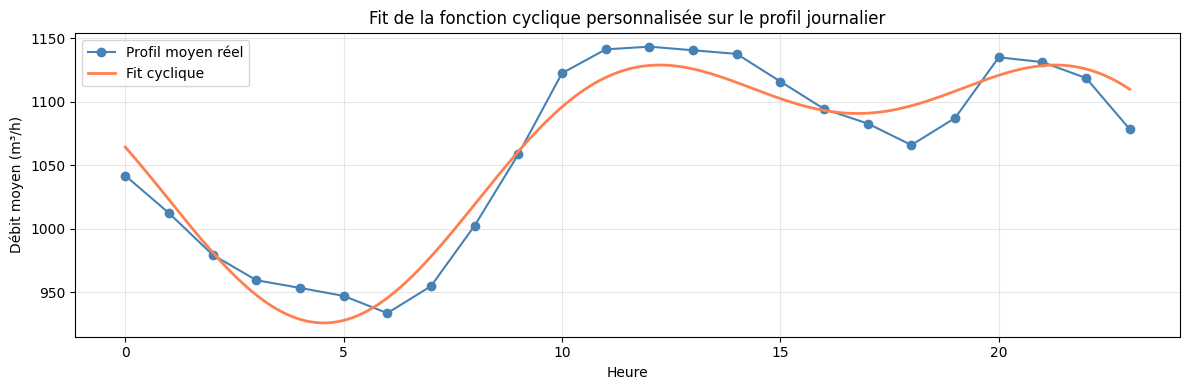


Feature cyclique créée : cyclic_custom (fit R² = 0.937)
Train      : 2021-01-02 → 2023-06-23  (20,016 obs)
Validation : 2023-06-23 → 2024-03-27  (6,672 obs)
Test       : 2024-03-27 → 2024-12-31  (6,673 obs)

MinMaxScaler appliqué sur 21 colonnes
Polynomial features ajoutées : 15 interactions
Total features : 39

max_depth retenu : 3
[0]	validation_0-rmse:529.34784
[50]	validation_0-rmse:195.59815
[100]	validation_0-rmse:180.57555
[150]	validation_0-rmse:176.85691
[200]	validation_0-rmse:175.46282
[250]	validation_0-rmse:174.57937
[300]	validation_0-rmse:173.97406
[350]	validation_0-rmse:173.81354
[400]	validation_0-rmse:173.84393
[450]	validation_0-rmse:173.92236
[499]	validation_0-rmse:173.78310

══════════════════════════════════════════════
   COMPARAISON — Modèle v2 vs Modèle Tuteur
══════════════════════════════════════════════

── Modèle v2 (baseline, max_depth=3) ──
Train        → RMSE=140.25 | MAE=82.43 | R²=0.852
Val          → RMSE=168.42 | MAE=104.10 | R²=0.862
Test        

In [17]:
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from scipy.optimize import minimize

# =====================================================================
# 1. FONCTION CYCLIQUE PERSONNALISÉE
# =====================================================================
# Modèle : f(h) = beta + alpha * cos(h * tau + phi)^2 + alpha2 * sin(h * tau + phi)
# On fit cette fonction sur le profil journalier moyen du débit

hourly_profile = df_3h.groupby(df_3h.index.hour)['debit'].mean()

def cyclic_model(params, hours):
    beta, alpha, tau, phi, alpha2 = params
    return beta + alpha * np.cos(hours * tau + phi)**2 + alpha2 * np.sin(hours * tau + phi)

def cyclic_loss(params, hours, y):
    return np.mean((cyclic_model(params, hours) - y)**2)

hours_arr = hourly_profile.index.values.astype(float)
y_profile = hourly_profile.values

# Optimisation avec plusieurs restarts pour éviter les minima locaux
best_loss = np.inf
best_params = None
for _ in range(50):
    x0 = [
        np.random.uniform(200, 600),      # beta
        np.random.uniform(-300, 300),      # alpha
        np.random.uniform(0.2, 0.4),       # tau  (~ 2*pi/24 ≈ 0.26)
        np.random.uniform(-np.pi, np.pi),  # phi
        np.random.uniform(-200, 200),      # alpha2
    ]
    res = minimize(cyclic_loss, x0, args=(hours_arr, y_profile), method='Nelder-Mead',
                   options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-8})
    if res.fun < best_loss:
        best_loss = res.fun
        best_params = res.x

beta_opt, alpha_opt, tau_opt, phi_opt, alpha2_opt = best_params
print(f"Paramètres optimaux : β={beta_opt:.1f}, α={alpha_opt:.1f}, τ={tau_opt:.4f}, φ={phi_opt:.3f}, α₂={alpha2_opt:.1f}")
print(f"Loss MSE : {best_loss:.1f}")

# Visualisation du fit
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hours_arr, y_profile, 'o-', label='Profil moyen réel', color='steelblue', ms=6)
h_fine = np.linspace(0, 23, 200)
ax.plot(h_fine, cyclic_model(best_params, h_fine), '-', label='Fit cyclique', color='coral', lw=2)
ax.set_xlabel('Heure')
ax.set_ylabel('Débit moyen (m³/h)')
ax.set_title('Fit de la fonction cyclique personnalisée sur le profil journalier')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Créer la feature cyclique pour tout le dataset
df_tuteur = df_3h_v2.copy()
df_tuteur['cyclic_custom'] = cyclic_model(best_params, df_tuteur.index.hour.values.astype(float))

# Résidu = écart du débit réel au profil cyclique (signal "surprenant")
df_tuteur['debit_residual_cyclic'] = df_tuteur['debit'] - df_tuteur['cyclic_custom']

print(f"\nFeature cyclique créée : cyclic_custom (fit R² = {1 - best_loss / np.var(y_profile):.3f})")


# =====================================================================
# 2. TRANSFORMATIONS PLUIE — exp + normalisation MinMax
# =====================================================================
rain_cols_raw = ['rain', 'rain_lag_1h', 'rain_lag_2h', 'rain_lag_3h', 'rain_lag_4h', 'rain_lag_5']

# Lags exponentiels de la pluie
for col in rain_cols_raw:
    df_tuteur[f'{col}_exp'] = np.expm1(df_tuteur[col])  # exp(x)-1 pour stabilité (exp(0)=0)

# =====================================================================
# 3. SÉLECTION DES FEATURES (avant normalisation et polynômes)
# =====================================================================
feature_cols_tuteur_base = [
    # Débit et inertie
    'debit', 'debit_lag_6h', 'debit_roll_mean_6h',
    'debit_roll_max_6h', 'debit_roll_min_6h',
    'debit_residual_cyclic',
    # Météo
    'temperature_2m', 'wind_speed_10m',
    # Pluie brute — lags
    'rain_lag_1h', 'rain_lag_2h', 'rain_lag_3h', 'rain_lag_4h', 'rain_lag_5',
    # Pluie rolling
    'rain_roll_sum_3h', 'rain_roll_sum_6h', 'rain_roll_sum_12h',
    'rain_roll_max_3h', 'rain_roll_max_6h',
    # Pluie exponentielle (normalisée ensuite)
    'rain_exp', 'rain_lag_1h_exp', 'rain_lag_2h_exp',
    # Épisode pluvieux
    'is_raining_now', 'hours_since_rain',
    # Temporel — uniquement la fonction cyclique personnalisée (remplace sin/cos)
    'cyclic_custom',
]

df_tuteur = df_tuteur.dropna(subset=feature_cols_tuteur_base + ['debit_target_3h'])

X_tut = df_tuteur[feature_cols_tuteur_base].copy()
y_tut = df_tuteur['debit_target_3h']

# =====================================================================
# 4. SPLIT 60/20/20
# =====================================================================
n = len(X_tut)
n_train = int(n * 0.60)
n_val   = int(n * 0.20)

X_train_tut = X_tut.iloc[:n_train].copy()
y_train_tut = y_tut.iloc[:n_train]
X_val_tut   = X_tut.iloc[n_train:n_train+n_val].copy()
y_val_tut   = y_tut.iloc[n_train:n_train+n_val]
X_test_tut  = X_tut.iloc[n_train+n_val:].copy()
y_test_tut  = y_tut.iloc[n_train+n_val:]

print(f"Train      : {X_train_tut.index.min().date()} → {X_train_tut.index.max().date()}  ({len(X_train_tut):,} obs)")
print(f"Validation : {X_val_tut.index.min().date()} → {X_val_tut.index.max().date()}  ({len(X_val_tut):,} obs)")
print(f"Test       : {X_test_tut.index.min().date()} → {X_test_tut.index.max().date()}  ({len(X_test_tut):,} obs)")

# =====================================================================
# 5. MinMax NORMALISATION sur pluie et débit
# =====================================================================
cols_minmax = [
    'debit', 'debit_lag_6h', 'debit_roll_mean_6h',
    'debit_roll_max_6h', 'debit_roll_min_6h', 'debit_residual_cyclic',
    'rain_lag_1h', 'rain_lag_2h', 'rain_lag_3h', 'rain_lag_4h', 'rain_lag_5',
    'rain_roll_sum_3h', 'rain_roll_sum_6h', 'rain_roll_sum_12h',
    'rain_roll_max_3h', 'rain_roll_max_6h',
    'rain_exp', 'rain_lag_1h_exp', 'rain_lag_2h_exp',
    'temperature_2m', 'wind_speed_10m',
]

scalers_tut = {}
for col in cols_minmax:
    scaler = MinMaxScaler()
    scaler.fit(X_train_tut[[col]])
    X_train_tut[col] = scaler.transform(X_train_tut[[col]])
    X_val_tut[col]   = scaler.transform(X_val_tut[[col]])
    X_test_tut[col]  = scaler.transform(X_test_tut[[col]])
    scalers_tut[col] = scaler

print(f"\nMinMaxScaler appliqué sur {len(cols_minmax)} colonnes")

# =====================================================================
# 6. POLYNOMIAL FEATURES (interactions degré 2)
# =====================================================================
# On applique les polynômes uniquement sur un sous-ensemble clé 
# pour éviter l'explosion combinatoire
cols_poly = ['debit', 'rain_lag_1h', 'rain_roll_sum_3h', 'rain_roll_max_3h',
             'temperature_2m', 'cyclic_custom']

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly.fit(X_train_tut[cols_poly])

poly_names = poly.get_feature_names_out(cols_poly)
# Ne garder que les interactions (pas les features originales déjà présentes)
new_poly_names = [n for n in poly_names if ' ' in n]  # interactions contiennent un espace

X_train_poly = pd.DataFrame(
    poly.transform(X_train_tut[cols_poly]),
    columns=poly_names, index=X_train_tut.index
)[new_poly_names]

X_val_poly = pd.DataFrame(
    poly.transform(X_val_tut[cols_poly]),
    columns=poly_names, index=X_val_tut.index
)[new_poly_names]

X_test_poly = pd.DataFrame(
    poly.transform(X_test_tut[cols_poly]),
    columns=poly_names, index=X_test_tut.index
)[new_poly_names]

# Concaténer
X_train_full = pd.concat([X_train_tut, X_train_poly], axis=1)
X_val_full   = pd.concat([X_val_tut, X_val_poly], axis=1)
X_test_full  = pd.concat([X_test_tut, X_test_poly], axis=1)

print(f"Polynomial features ajoutées : {len(new_poly_names)} interactions")
print(f"Total features : {X_train_full.shape[1]}")

# =====================================================================
# 7. ENTRAÎNEMENT — XGBoost avec depth optimal
# =====================================================================
# On utilise le best_d trouvé à l'étape 1 (ou 5 par défaut)
depth_final = best_d if 'best_d' in dir() else 5
print(f"\nmax_depth retenu : {depth_final}")

model_tuteur = xgb.XGBRegressor(
    max_depth=depth_final,
    n_estimators=500,
    learning_rate=0.05,
    reg_alpha=1.0,
    reg_lambda=5.0,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_tuteur.fit(
    X_train_full, y_train_tut,
    eval_set=[(X_val_full, y_val_tut)],
    verbose=50
)

yp_tr_tut = model_tuteur.predict(X_train_full)
yp_va_tut = model_tuteur.predict(X_val_full)
yp_te_tut = model_tuteur.predict(X_test_full)

print("\n══════════════════════════════════════════════")
print("   COMPARAISON — Modèle v2 vs Modèle Tuteur")
print("══════════════════════════════════════════════")

print("\n── Modèle v2 (baseline, max_depth=3) ──")
print_metrics("Train", y_train_v2, model_v2.predict(X_train_v2))
print_metrics("Val",   y_val_v2,   model_v2.predict(X_val_v2))
print_metrics("Test",  y_test_v2,  model_v2.predict(X_test_v2))

print(f"\n── Modèle Tuteur (depth={depth_final}, {X_train_full.shape[1]} features) ──")
print_metrics("Train", y_train_tut, yp_tr_tut)
print_metrics("Val",   y_val_tut,   yp_va_tut)
print_metrics("Test",  y_test_tut,  yp_te_tut)

gap_r2 = r2_score(y_train_tut, yp_tr_tut) - r2_score(y_test_tut, yp_te_tut)
print(f"\nGap R² (train−test) : {gap_r2:.3f}")
print(f"{'⚠️ Overfit détecté' if gap_r2 > 0.10 else '✅ Overfit acceptable'}")

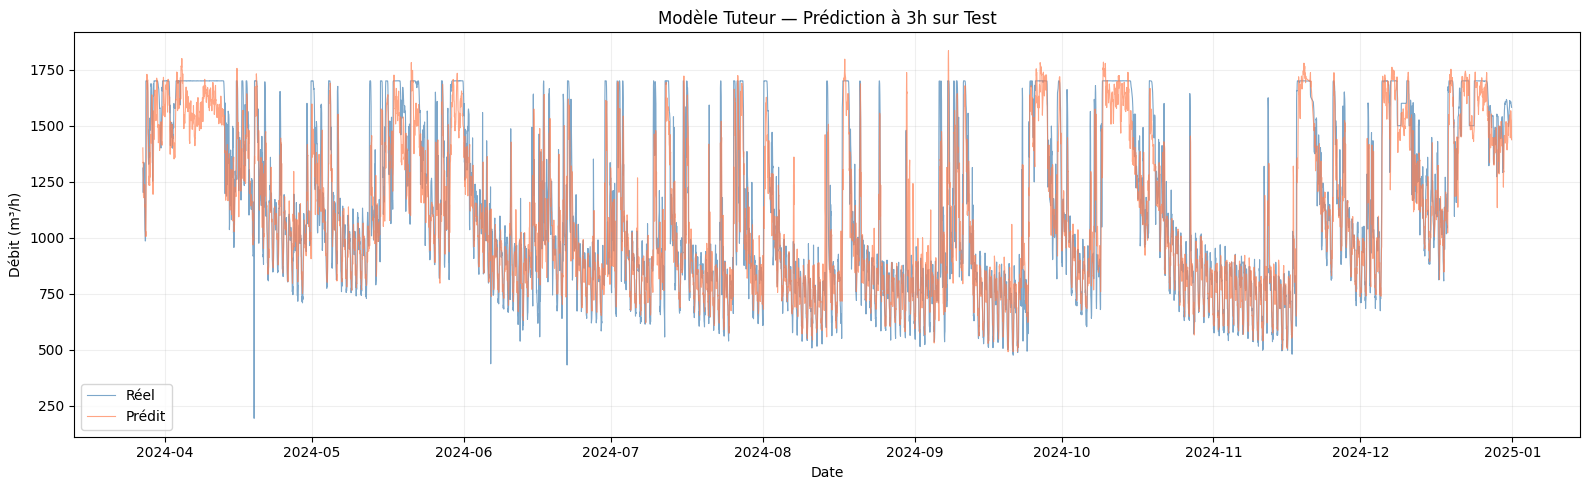

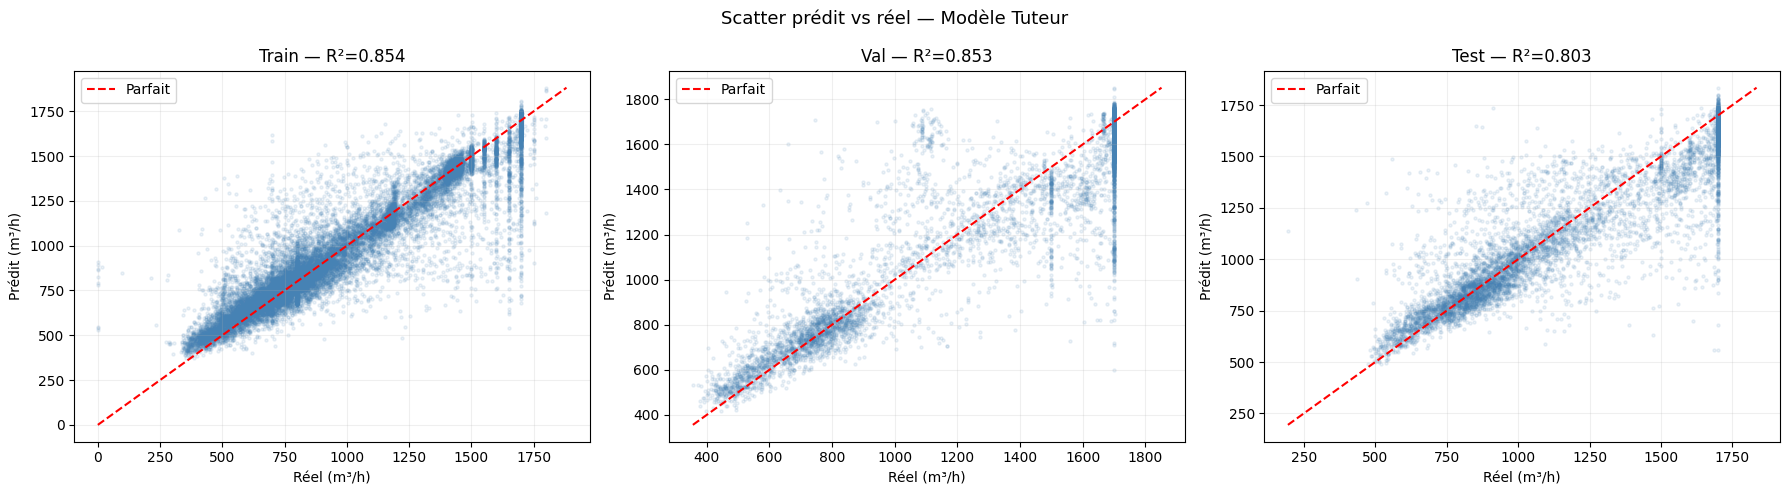

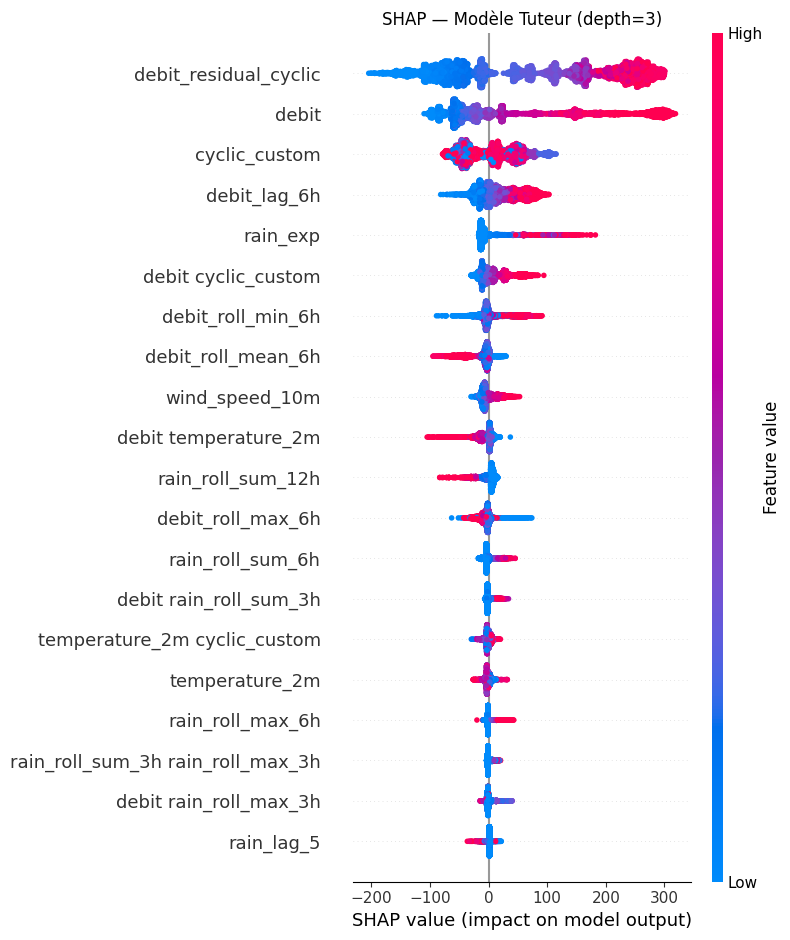

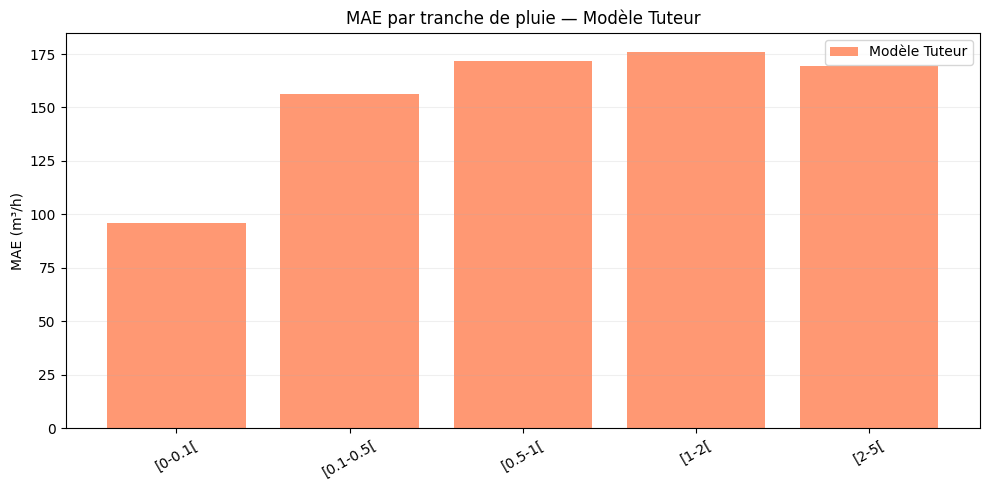


── Focus épisodes pluvieux (rain > 2.0 mm/h) : 107 obs ──
Tuteur pluie → RMSE=283.33 | MAE=180.44 | R²=0.238
Tuteur sec   → RMSE=164.52 | MAE=108.88 | R²=0.806


In [18]:
# =====================================================================
# VISUALISATION & SHAP — Modèle Tuteur
# =====================================================================

# --- 1. Prédiction vs Réel sur le Test ---
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test_tut.index, y_test_tut.values, color='steelblue', alpha=0.7, lw=0.8, label='Réel')
ax.plot(y_test_tut.index, yp_te_tut, color='coral', alpha=0.7, lw=0.8, label='Prédit')
ax.set_xlabel('Date')
ax.set_ylabel('Débit (m³/h)')
ax.set_title(f'Modèle Tuteur — Prédiction à 3h sur Test')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# --- 2. Scatter prédit vs réel ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, yt, yp) in zip(axes, [
    ('Train', y_train_tut, yp_tr_tut),
    ('Val',   y_val_tut,   yp_va_tut),
    ('Test',  y_test_tut,  yp_te_tut),
]):
    ax.scatter(yt, yp, alpha=0.1, s=5, color='steelblue')
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Parfait')
    ax.set_xlabel('Réel (m³/h)')
    ax.set_ylabel('Prédit (m³/h)')
    r2 = r2_score(yt, yp)
    ax.set_title(f'{label} — R²={r2:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.2)
plt.suptitle('Scatter prédit vs réel — Modèle Tuteur', fontsize=13)
plt.tight_layout()
plt.show()

# --- 3. SHAP (top 20 features) ---
explainer_tut = shap.TreeExplainer(model_tuteur)
shap_values_tut = explainer_tut.shap_values(X_test_full)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_tut, X_test_full, max_display=20, show=False)
plt.title(f'SHAP — Modèle Tuteur (depth={depth_final})')
plt.tight_layout()
plt.show()

# --- 4. Erreur par tranche de pluie (comparaison v2 vs tuteur) ---
rain_test_tut = df_tuteur.loc[X_test_tut.index, 'rain'].values if 'rain' in df_tuteur.columns else df_tuteur.loc[X_test_tut.index, 'rain_lag_1h'].values
errors_tut = y_test_tut.values - yp_te_tut

tranches = [0, 0.1, 0.5, 1, 2, 5, 10, 100]
labels_t, mae_tut_t = [], []
for low, high in zip(tranches[:-1], tranches[1:]):
    mask = (rain_test_tut >= low) & (rain_test_tut < high)
    if mask.sum() > 10:
        labels_t.append(f'[{low}-{high}[')
        mae_tut_t.append(np.mean(np.abs(errors_tut[mask])))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels_t))
ax.bar(x, mae_tut_t, color='coral', alpha=0.8, label='Modèle Tuteur')
ax.set_xticks(x)
ax.set_xticklabels(labels_t, rotation=30)
ax.set_ylabel('MAE (m³/h)')
ax.set_title('MAE par tranche de pluie — Modèle Tuteur')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

# --- 5. Focus épisodes pluvieux ---
SEUIL = 2.0
rain_mask_tut = rain_test_tut > SEUIL
print(f"\n── Focus épisodes pluvieux (rain > {SEUIL} mm/h) : {rain_mask_tut.sum()} obs ──")
if rain_mask_tut.sum() > 0:
    print_metrics("Tuteur pluie", y_test_tut.values[rain_mask_tut], yp_te_tut[rain_mask_tut])
    print_metrics("Tuteur sec",   y_test_tut.values[~rain_mask_tut], yp_te_tut[~rain_mask_tut])

## Étape 3 : Optimisation des hyperparamètres

### 3a. Early Stopping
On arrête l'entraînement quand la validation ne s'améliore plus → évite le surentraînement, modèle plus léger.

### 3b. RandomizedSearchCV
Recherche aléatoire sur une grille large de 6 hyperparamètres avec **TimeSeriesSplit** (3 folds).
On optimise conjointement : `learning_rate`, `n_estimators`, `max_depth`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`.

In [19]:
# =====================================================================
# ÉTAPE 3a — Early Stopping sur le modèle Tuteur
# =====================================================================
# On relance le modèle tuteur avec early_stopping_rounds pour trouver
# le nombre optimal d'arbres (au lieu de 500 fixe)

model_es = xgb.XGBRegressor(
    max_depth=depth_final,
    n_estimators=2000,          # plafond haut — early stopping arrêtera avant
    learning_rate=0.05,
    reg_alpha=1.0,
    reg_lambda=5.0,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=30,   # arrête si 30 rounds sans amélioration
)
model_es.fit(
    X_train_full, y_train_tut,
    eval_set=[(X_val_full, y_val_tut)],
    verbose=50
)

best_n = model_es.best_iteration + 1
print(f"\n✅ Early Stopping : meilleur n_estimators = {best_n} (sur 2000 max)")
print(f"   Best validation RMSE = {model_es.best_score:.2f}")

yp_tr_es = model_es.predict(X_train_full)
yp_va_es = model_es.predict(X_val_full)
yp_te_es = model_es.predict(X_test_full)

print(f"\n── Modèle Tuteur SANS early stopping (500 arbres) ──")
print_metrics("Train", y_train_tut, yp_tr_tut)
print_metrics("Val",   y_val_tut,   yp_va_tut)
print_metrics("Test",  y_test_tut,  yp_te_tut)

print(f"\n── Modèle Tuteur AVEC early stopping ({best_n} arbres) ──")
print_metrics("Train", y_train_tut, yp_tr_es)
print_metrics("Val",   y_val_tut,   yp_va_es)
print_metrics("Test",  y_test_tut,  yp_te_es)

gap_es = r2_score(y_train_tut, yp_tr_es) - r2_score(y_test_tut, yp_te_es)
print(f"\nGap R² (train−test) : {gap_es:.3f}")

# =====================================================================
# ÉTAPE 3b — RandomizedSearchCV
# =====================================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

print("\n" + "="*60)
print("   RANDOMIZED SEARCH CV — Optimisation conjointe")
print("="*60)

param_distributions = {
    'max_depth':        randint(2, 7),                # 2, 3, 4, 5, 6
    'learning_rate':    uniform(0.01, 0.14),           # 0.01 → 0.15
    'n_estimators':     randint(200, 1000),            # 200 → 1000
    'subsample':        uniform(0.5, 0.5),             # 0.5 → 1.0
    'colsample_bytree': uniform(0.5, 0.5),             # 0.5 → 1.0
    'reg_alpha':        uniform(0.0, 5.0),             # 0.0 → 5.0
    'reg_lambda':       uniform(1.0, 10.0),            # 1.0 → 11.0
    'min_child_weight': randint(1, 20),                # 1 → 20
}

# TimeSeriesSplit pour respecter l'ordre chronologique
# On concatène train+val pour le CV, puis on évalue sur test
X_cv = pd.concat([X_train_full, X_val_full])
y_cv = pd.concat([y_train_tut, y_val_tut])

tscv = TimeSeriesSplit(n_splits=3)

xgb_cv = xgb.XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    xgb_cv,
    param_distributions=param_distributions,
    n_iter=80,                # 80 combinaisons aléatoires
    cv=tscv,
    scoring='neg_mean_absolute_error',  # MAE (plus interprétable que MSE)
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

random_search.fit(X_cv, y_cv)

print(f"\n✅ Meilleurs hyperparamètres trouvés :")
for k, v in random_search.best_params_.items():
    print(f"   {k:20s} = {v}")
print(f"\n   Best CV MAE = {-random_search.best_score_:.2f} m³/h")

# Évaluation du meilleur modèle sur Test
model_best = random_search.best_estimator_
yp_tr_best = model_best.predict(X_train_full)
yp_va_best = model_best.predict(X_val_full)
yp_te_best = model_best.predict(X_test_full)

print(f"\n── Modèle Tuteur (avant tuning) ──")
print_metrics("Train", y_train_tut, yp_tr_tut)
print_metrics("Val",   y_val_tut,   yp_va_tut)
print_metrics("Test",  y_test_tut,  yp_te_tut)

print(f"\n── Meilleur modèle (RandomizedSearchCV) ──")
print_metrics("Train", y_train_tut, yp_tr_best)
print_metrics("Val",   y_val_tut,   yp_va_best)
print_metrics("Test",  y_test_tut,  yp_te_best)

gap_best = r2_score(y_train_tut, yp_tr_best) - r2_score(y_test_tut, yp_te_best)
print(f"\nGap R² (train−test) : {gap_best:.3f}")

# Re-entraîner le meilleur modèle avec early stopping pour affiner
best_params_found = random_search.best_params_.copy()
best_params_found['n_estimators'] = 2000  # plafond, early stopping arrêtera
best_params_found['early_stopping_rounds'] = 30
best_params_found['random_state'] = 42

model_final = xgb.XGBRegressor(**best_params_found)
model_final.fit(
    X_train_full, y_train_tut,
    eval_set=[(X_val_full, y_val_tut)],
    verbose=50
)

yp_tr_final = model_final.predict(X_train_full)
yp_va_final = model_final.predict(X_val_full)
yp_te_final = model_final.predict(X_test_full)

print(f"\n── Meilleur modèle + Early Stopping ({model_final.best_iteration+1} arbres) ──")
print_metrics("Train", y_train_tut, yp_tr_final)
print_metrics("Val",   y_val_tut,   yp_va_final)
print_metrics("Test",  y_test_tut,  yp_te_final)

gap_final = r2_score(y_train_tut, yp_tr_final) - r2_score(y_test_tut, yp_te_final)
print(f"Gap R² (train−test) : {gap_final:.3f}")

[0]	validation_0-rmse:529.34784
[50]	validation_0-rmse:195.59815
[100]	validation_0-rmse:180.57555
[150]	validation_0-rmse:176.85691
[200]	validation_0-rmse:175.46282
[250]	validation_0-rmse:174.57937
[300]	validation_0-rmse:173.97406
[350]	validation_0-rmse:173.81354
[394]	validation_0-rmse:173.95120

✅ Early Stopping : meilleur n_estimators = 365 (sur 2000 max)
   Best validation RMSE = 173.69

── Modèle Tuteur SANS early stopping (500 arbres) ──
Train        → RMSE=139.27 | MAE=85.27 | R²=0.854
Val          → RMSE=173.78 | MAE=109.83 | R²=0.853
Test         → RMSE=167.09 | MAE=110.03 | R²=0.803

── Modèle Tuteur AVEC early stopping (365 arbres) ──
Train        → RMSE=143.88 | MAE=88.43 | R²=0.844
Val          → RMSE=173.69 | MAE=109.87 | R²=0.853
Test         → RMSE=166.30 | MAE=109.74 | R²=0.805

Gap R² (train−test) : 0.039

   RANDOMIZED SEARCH CV — Optimisation conjointe
Fitting 3 folds for each of 80 candidates, totalling 240 fits

✅ Meilleurs hyperparamètres trouvés :
   colsam